In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
### Custom colors
colors = [
    "#cecece",  # grey
    "#a559aa",  # purple
    "#59a89c",  # teal
    "#f0c571",  # gold
    "#e02b35",  # red
    "#082a54",  # dark blue
]


### HESA Table 4 

### Ethnicity

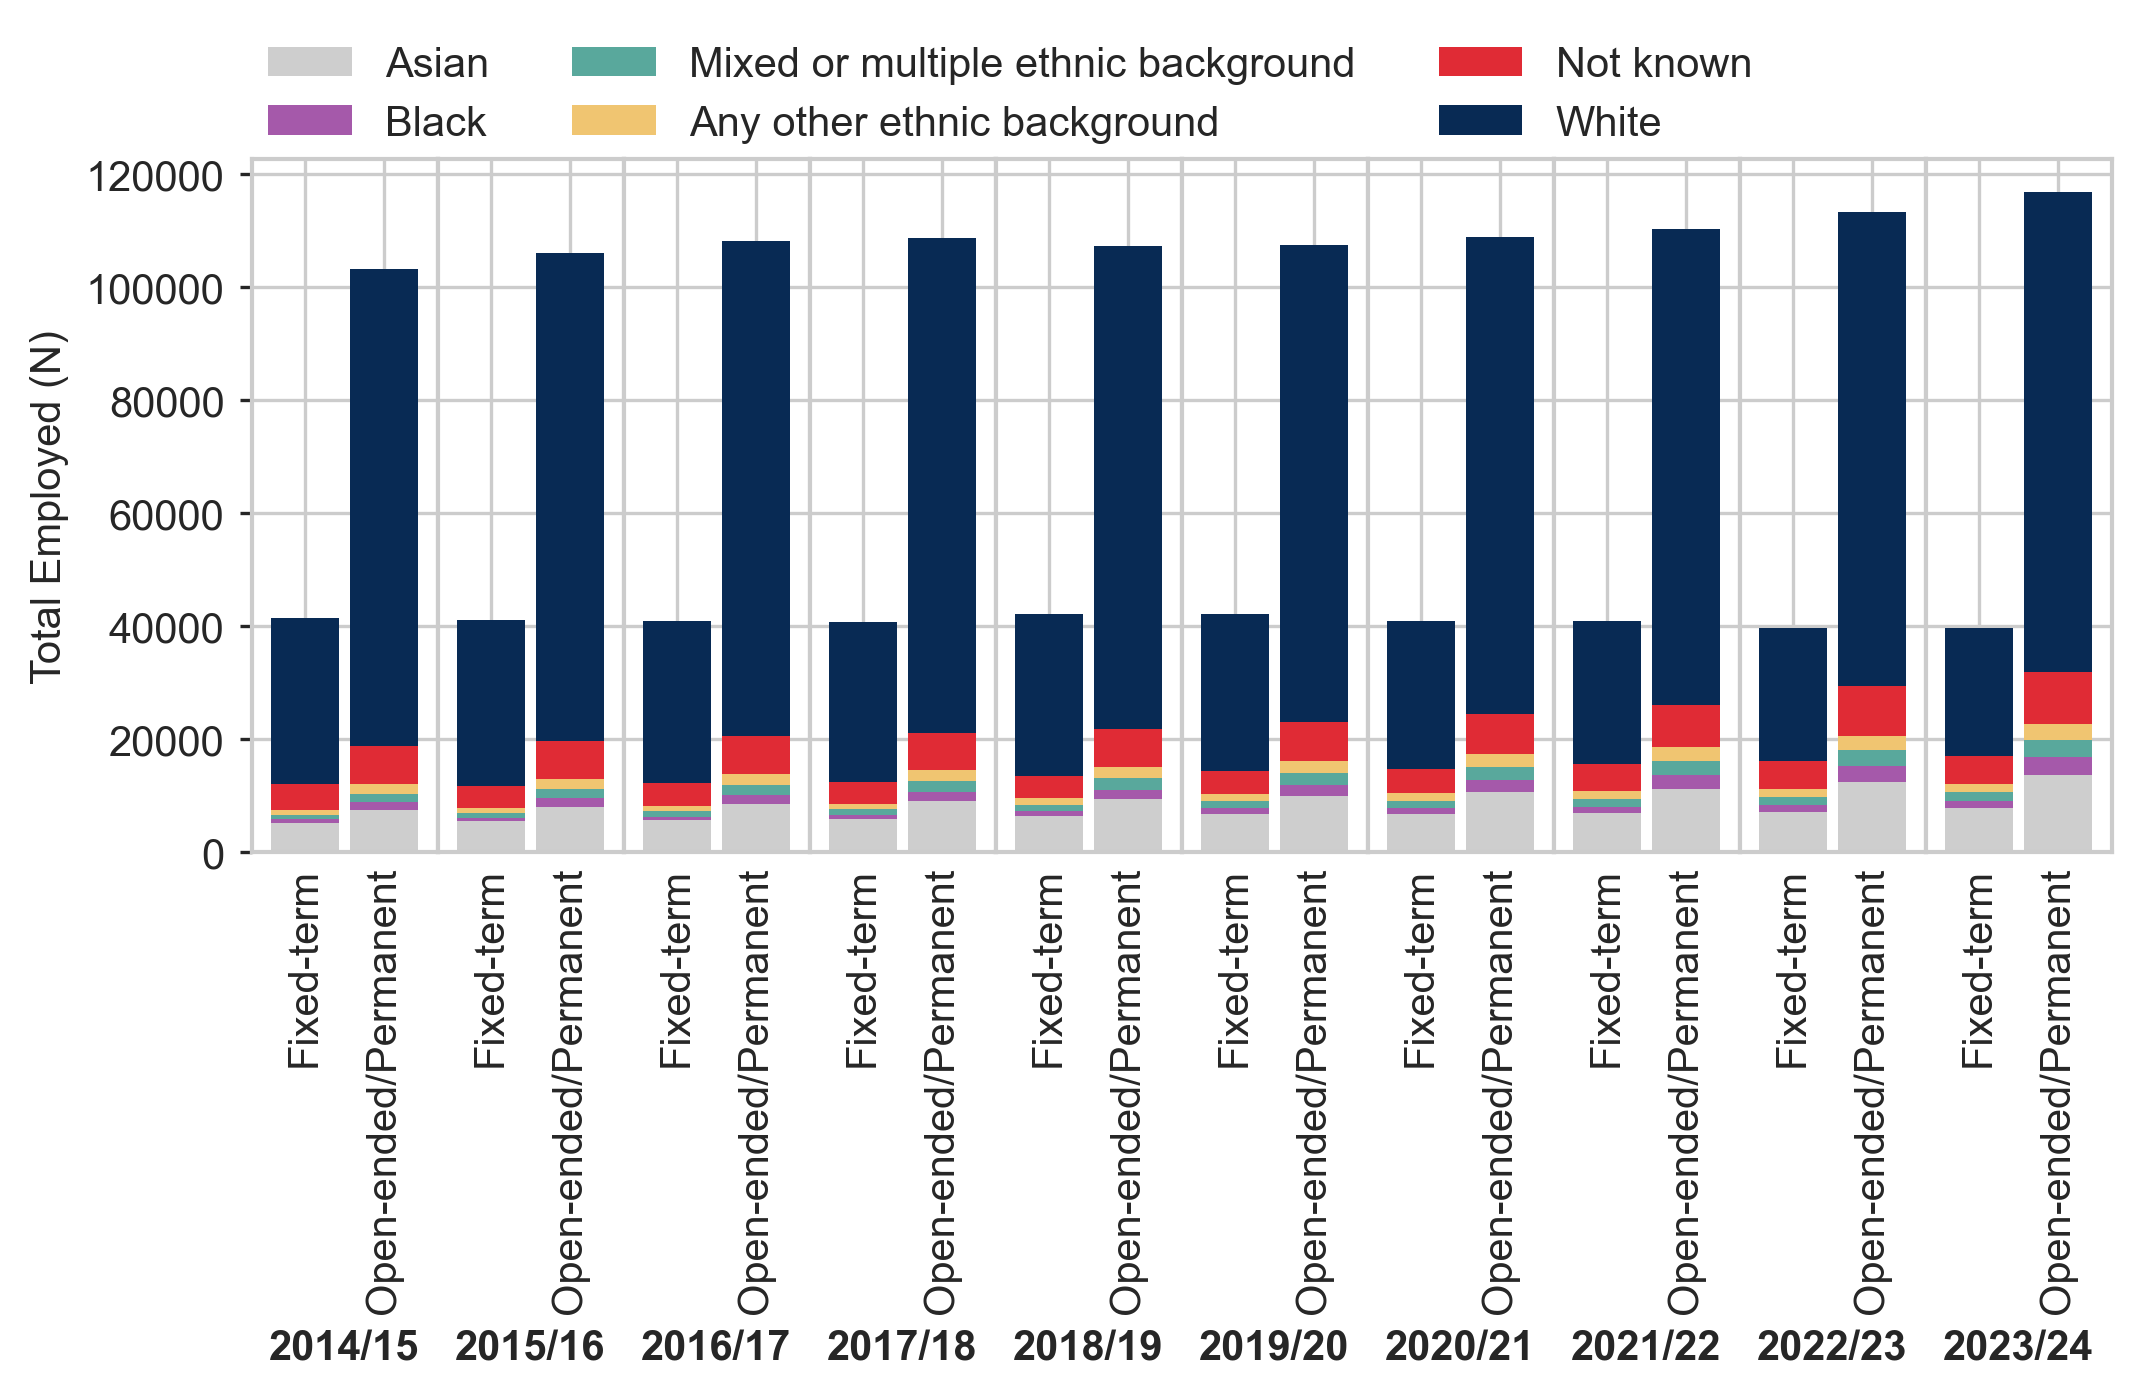

2014 total fixed-term staff = 41465
2024 total fixed-term staff = 39735
 Change in fixed-term staff = -1730
++++++++++++++++++++++++++++++++++++
2014 total permanent staff = 103320
2024 total permanent staff = 116840
 Change in permanent staff = 13520
40998.0


In [ ]:
# read in staff ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\table-4.csv"
df = pd.read_csv(path, header=22)

# Filter for TNR and R contracts
filtered_df = df[df['Academic employment function'].str.contains('Research only|Both teaching and research', case=False, na=False) &
                 df['Sex'].str.contains('All', case=False, na=False) &
                 df['Mode of employment'].str.contains('All', case=False, na=False) &
                 df['Country of HE provider'].str.contains('All', case=False, na=False) &
                 df['Terms of employment'].str.contains('Fixed-term|Open-ended/Permanent', case=False, na=False) &
                 df['Nationality marker'].str.contains('All', case=False, na=False)].copy()


# Pivot the DataFrame to create multi index by characteristics of interest
df_pivot = filtered_df.pivot(index=['Academic year','Terms of employment','Academic employment function'], columns=['Ethnicity'], values='Number')


# Combine ethnicity stats to match UKRI breakdown catagories and create new dataframe copy
df_pivot['Asian'] = df_pivot.filter(like='Asian',axis=1).sum(axis=1)
df_pivot['Black'] = df_pivot.filter(like='Black',axis=1).sum(axis=1)
df_employment_terms = df_pivot[['White','Asian','Black','Mixed or multiple ethnic background','Not known','Any other ethnic background','Total academic staff']].copy()

df_employment_terms = df_employment_terms.groupby(level=[0,1]).sum().copy()

#convert into percentages of total employed staff
df_normalised_employ_terms = df_employment_terms.div(df_employment_terms['Total academic staff'],axis=0) * 100


# Take colors at regular intervals spanning the colormap.
# cmap = mpl.colormaps['seaborn-v0_8-colorblind']
# colors = cmap(np.linspace(0, 1, 6))

df_plotting = df_employment_terms[['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background','Not known','White']].copy()

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3), dpi=300  )


graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

#axes[0].set_ylim(50,105)

# for ax in axes:
#     ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Total Employed (N)')
plt.legend(ncols=3, frameon=False, loc=(-9,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_employment_terms_data_N.svg'
fname_tiff = 'HESA_employment_terms_data_N.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

# plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
# plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'2014 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print(f'2024 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1]}')
print('======================')
print(f' Change in fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print('++++++++++++++++++++++++++++++++++++')
print(f'2014 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')
print(f'2024 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1]}')
print('======================')
print(f' Change in permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')
print('=====================')
print(df_employment_terms['Total academic staff'].iloc[0::2].mean())

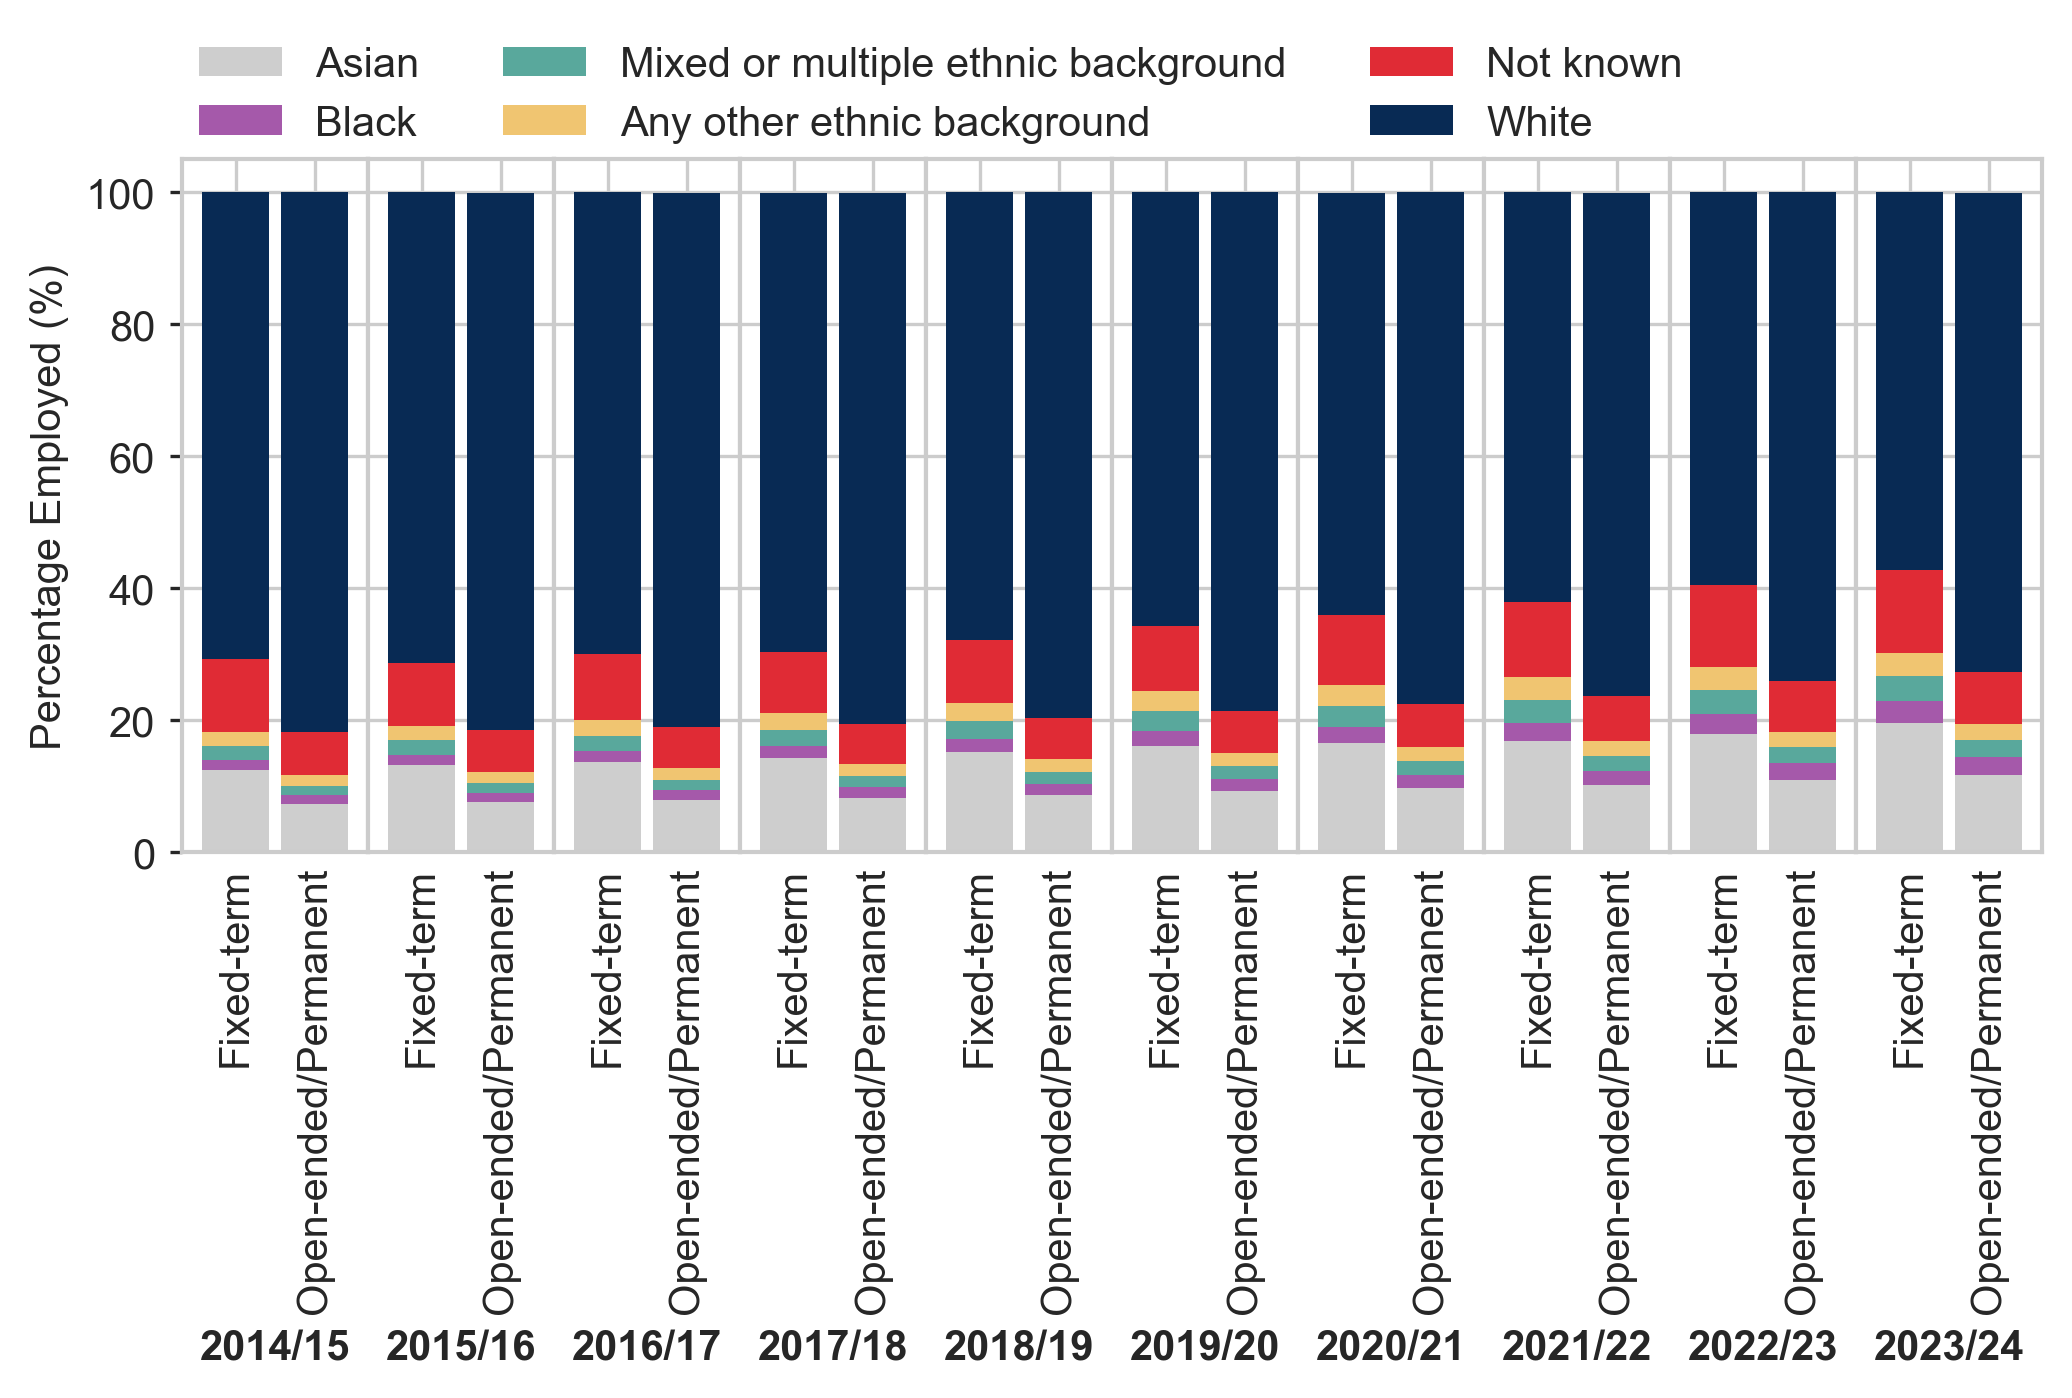

2014 total fixed-term staff = 41465
2024 total fixed-term staff = 39735
 Change in fixed-term staff = -1730
++++++++++++++++++++++++++++++++++++
2014 total permanent staff = 103320
2024 total permanent staff = 116840
 Change in permanent staff = 13520


In [4]:
df_plotting = df_normalised_employ_terms[['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background','Not known','White']].copy()

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3), dpi=300  )


graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

#axes[0].set_ylim(50,105)

# for ax in axes:
#     ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Percentage Employed (%)')
plt.legend(ncols=3, frameon=False, loc=(-9,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_employment_terms_data_percentage.svg'
fname_tiff = 'HESA_employment_terms_data_percentage.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

#plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
#plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'2014 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print(f'2024 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1]}')
print('======================')
print(f' Change in fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print('++++++++++++++++++++++++++++++++++++')
print(f'2014 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')
print(f'2024 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1]}')
print('======================')
print(f' Change in permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')

In [60]:
df_plotting.loc[['2014/15','2020/21']]

Ethnicity                              Asian     Black  \
Academic year Terms of employment                        
2014/15       Fixed-term           12.540697  1.447003   
              Permanent             7.283198  1.345335   
2020/21       Fixed-term           16.493966  2.474704   
              Permanent             9.780265  1.899170   

Ethnicity                          Mixed or multiple ethnic background  \
Academic year Terms of employment                                        
2014/15       Fixed-term                                      2.061980   
              Permanent                                       1.384050   
2020/21       Fixed-term                                      3.193953   
              Permanent                                       2.156062   

Ethnicity                          Any other ethnic background  Not known  \
Academic year Terms of employment                                           
2014/15       Fixed-term                              2.110213  11.093693   
              Permanent                               1.630856   6.625048   
2020/21       Fixed-term                              3.218335  10.532732   
              Permanent                               2.133125   6.477361   

Ethnicity                              White  
Academic year Terms of employment             
2014/15       Fixed-term           70.746413  
              Permanent            81.736353  
2020/21       Fixed-term           64.061929  
              Permanent            77.554016

C:\Users\ct832900\AppData\Local\Temp\ipykernel_284\2773517864.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(np.linspace(0,100,5).astype(int), color='white')


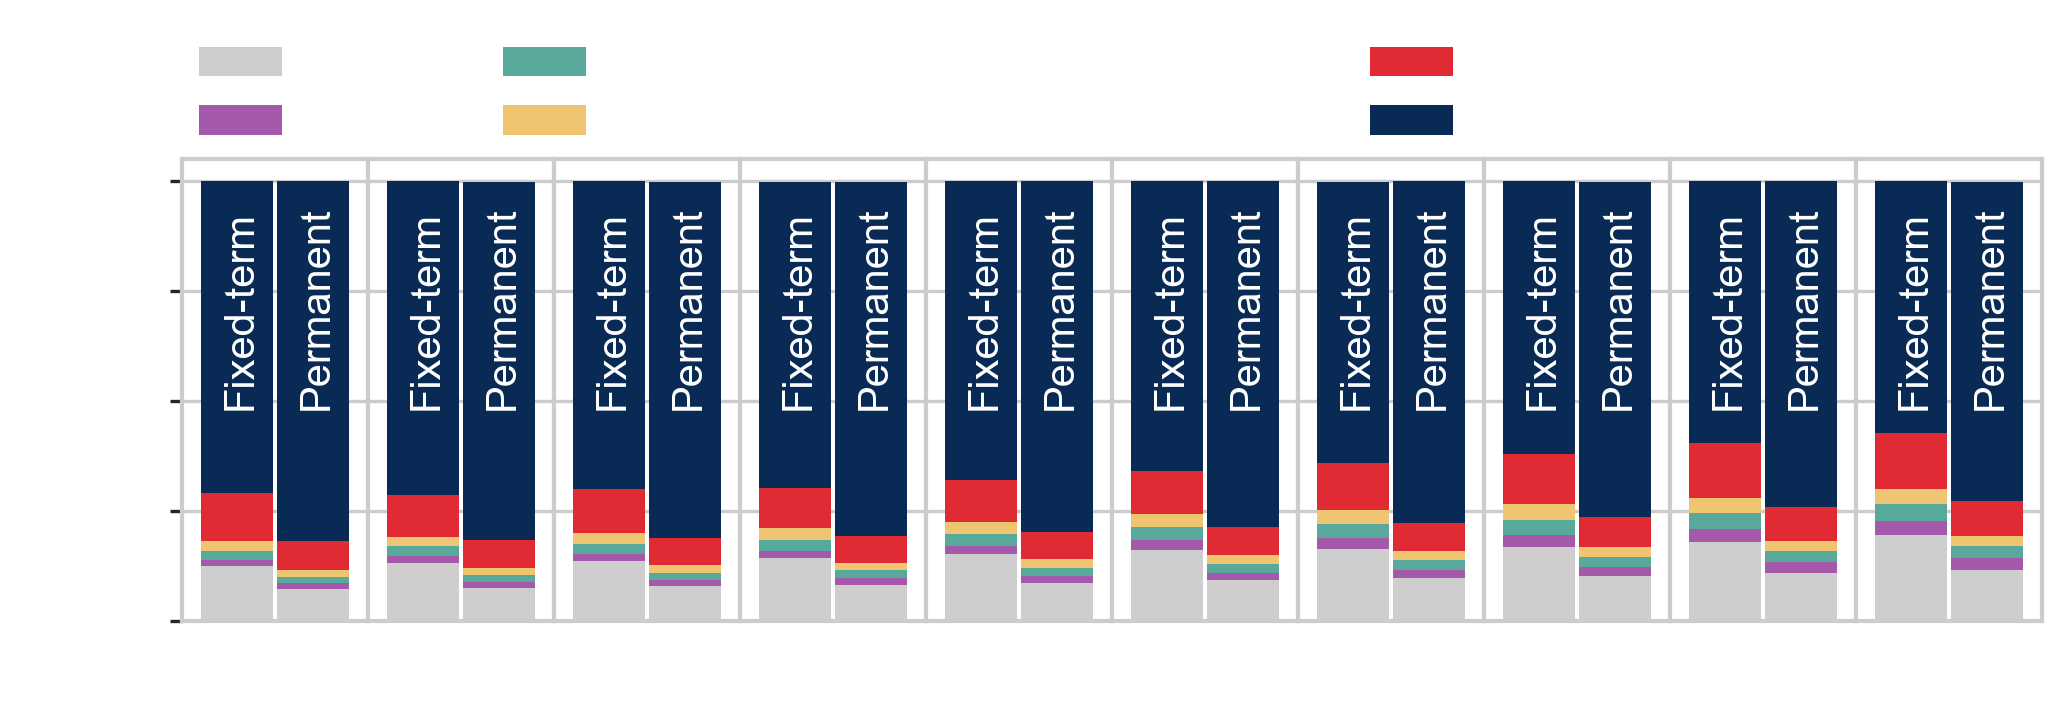

2014 total fixed-term staff = 41465
2024 total fixed-term staff = 39735
 Change in fixed-term staff = -1730
++++++++++++++++++++++++++++++++++++
2014 total permanent staff = 103320
2024 total permanent staff = 116840
 Change in permanent staff = 13520


In [ ]:
#================================
# Figure formatting for graphical abstract

df_plotting = df_normalised_employ_terms[['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background','Not known','White']].copy()
#df_plotting.index = df_plotting.index.set_levels(np.arange(2014, 2025), level=0)
df_plotting.index = df_plotting.index.set_levels(['Fixed-term', 'Permanent'], level=1)

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 2), dpi=300  )


graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.95, color=colors).set_xlabel(x, weight='bold', color='white'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

#axes[0].set_ylim(50,105)

# for ax in axes:
#     ax.tick_params(axis='x', rotation=30)

axes[0].set_yticklabels(np.linspace(0,100,5).astype(int), color='white')

for ax in axes:
    ax.set_xticks([])
    ax.annotate('Fixed-term', (-0.2,50), color='white', rotation=90)
    ax.annotate('Permanent', (0.8,50), color='white', rotation=90)


axes[0].set_ylabel('Percentage Employed (%)', color='white')
plt.legend(ncols=3, frameon=False, loc=(-9,1), labelcolor='white')
fig.subplots_adjust(wspace=0)

fname = 'HESA_employment_terms_data_percentage_squashed.svg'
fname_tiff = 'HESA_employment_terms_data_percentage.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

#plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
#plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'2014 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print(f'2024 total fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1]}')
print('======================')
print(f' Change in fixed-term staff = {df_employment_terms['Total academic staff'].iloc[0::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[0::2].iloc[0]}')
print('++++++++++++++++++++++++++++++++++++')
print(f'2014 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')
print(f'2024 total permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1]}')
print('======================')
print(f' Change in permanent staff = {df_employment_terms['Total academic staff'].iloc[1::2].iloc[-1] - df_employment_terms['Total academic staff'].iloc[1::2].iloc[0]}')

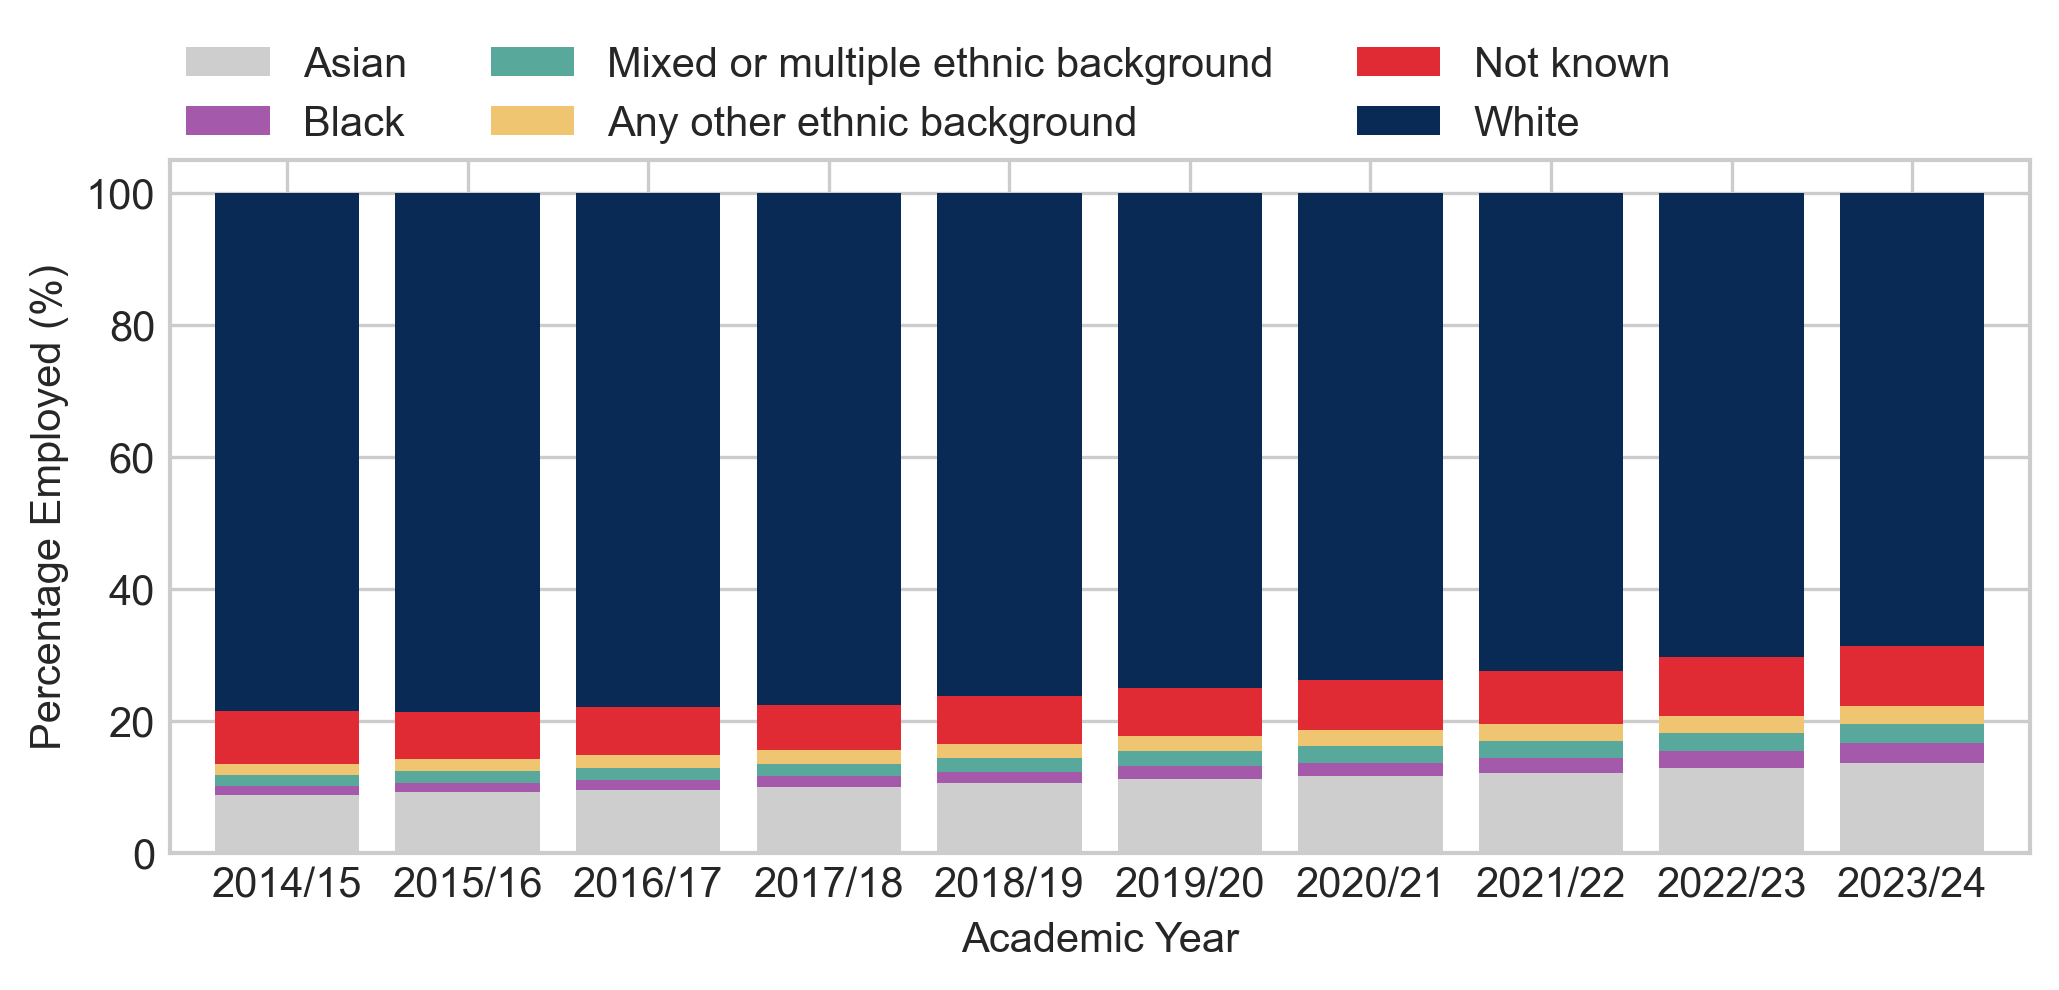

In [ ]:
# read in staff ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\table-4.csv"
df = pd.read_csv(path, header=22)

# Filter for TNR and R contracts
filtered_df = df[df['Academic employment function'].str.contains('Research only|Both teaching and research', case=False, na=False) &
                 df['Sex'].str.contains('All', case=False, na=False) &
                 df['Mode of employment'].str.contains('All', case=False, na=False) &
                 df['Country of HE provider'].str.contains('All', case=False, na=False) &
                 df['Terms of employment'].str.contains('All', case=False, na=False) &
                 df['Nationality marker'].str.contains('All', case=False, na=False)].copy()


# Pivot the DataFrame to create multi index by characteristics of interest
df_pivot = filtered_df.pivot(index=['Academic year','Academic employment function'], columns=['Ethnicity'], values='Number')

df_pivot
# Combine ethnicity stats to match UKRI breakdown catagories and create new dataframe copy
df_pivot['Asian'] = df_pivot.filter(like='Asian',axis=1).sum(axis=1)
df_pivot['Black'] = df_pivot.filter(like='Black',axis=1).sum(axis=1)
df_total = df_pivot[['White','Asian','Black','Mixed or multiple ethnic background','Not known','Any other ethnic background','Total academic staff']].copy()

df_total = df_total.groupby(level=[0]).sum().copy()

#convert into percentages of total employed staff
df_normalised = df_total.div(df_total['Total academic staff'],axis=0) * 100


fig, ax = plt.subplots(1,1, dpi=300, figsize=(8,3))
df_all_staff = df_normalised.copy()
df_all_staff[['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background','Not known','White']].plot(kind='bar', stacked=True, width=0.8, color=colors, ax=ax)

plt.xlabel('Academic Year')
plt.ylabel('Percentage Employed (%)')
plt.legend(ncols=3, frameon=False, loc=(0,1))
plt.xticks(rotation=0)

#plt.ylim(50,105)

fname = 'HESA_all_data_percentages.svg'
fname_tiff = 'HESA_all_data_percentages.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')



plt.show()


### Gender

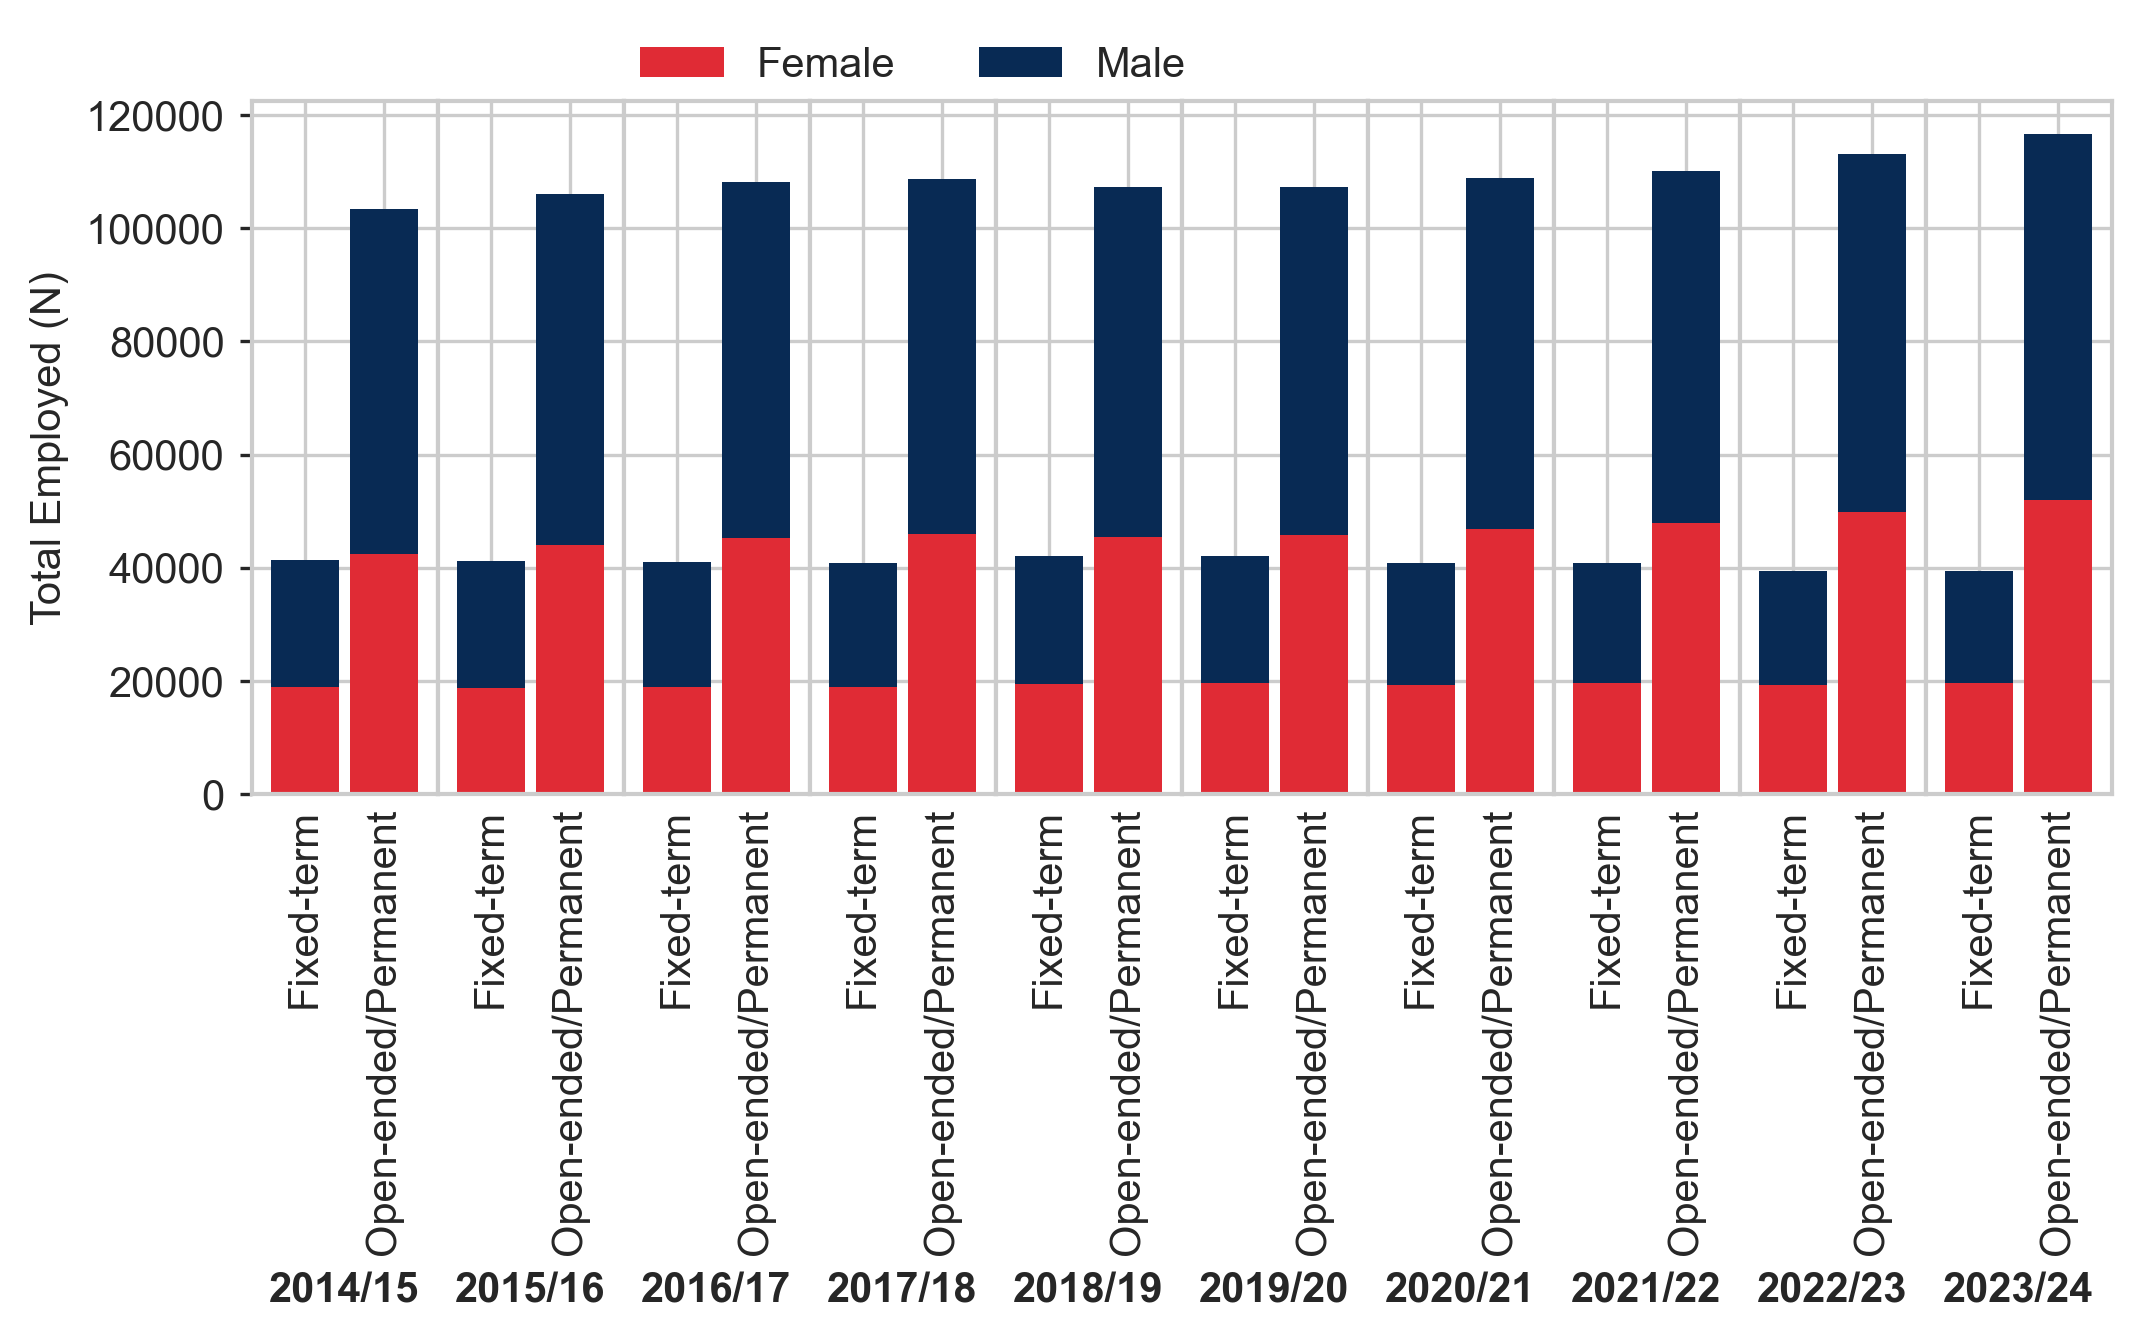

In [48]:
# Filter for female and male staff data
filtered_df = df[df['Academic employment function'].str.contains('Research only|Both teaching and research', case=False, na=False) &
                 df['Sex'].str.contains('Female|Male', case=False, na=False) &
                 df['Mode of employment'].str.contains('All', case=False, na=False) &
                 df['Country of HE provider'].str.contains('All', case=False, na=False) &
                 df['Terms of employment'].str.contains('Fixed-term|Open-ended/Permanent', case=False, na=False) &
                 df['Nationality marker'].str.contains('All', case=False, na=False)].copy()

# Pivot the DataFrame 
df_pivot = filtered_df.pivot(index=['Academic year','Academic employment function','Terms of employment','Sex'], columns=['Ethnicity'], values='Number')


# Combine ethnicity stats to match UKRI breakdown catagories and create new dataframe copy
df_pivot['Asian'] = df_pivot.filter(like='Asian',axis=1).sum(axis=1)
df_pivot['Black'] = df_pivot.filter(like='Black',axis=1).sum(axis=1)

df_gender_emply_trms = pd.DataFrame(df_pivot[['White','Asian','Black','Mixed or multiple ethnic background','Not known','Any other ethnic background']].sum(axis=1).copy())
df_gender_emply_trms = df_gender_emply_trms.groupby(level=[0,2,3]).sum().copy()
df_gender_emply_trms = df_gender_emply_trms.reset_index().pivot(index=['Academic year','Terms of employment'], columns='Sex',values=0)
df_gender_emply_trms['Total academic staff'] = df_gender_emply_trms['Male'] + df_gender_emply_trms['Female']


df_plotting = df_gender_emply_trms[['Female','Male']].copy()

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3), dpi=300)

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=["#e02b35", "#082a54"]).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

axes[0].set_ylabel('Total Employed (N)')
plt.legend(ncols=3, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_gender_employment_terms_N.svg'
fname_tiff = 'HESA_gender_employment_terms_N.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

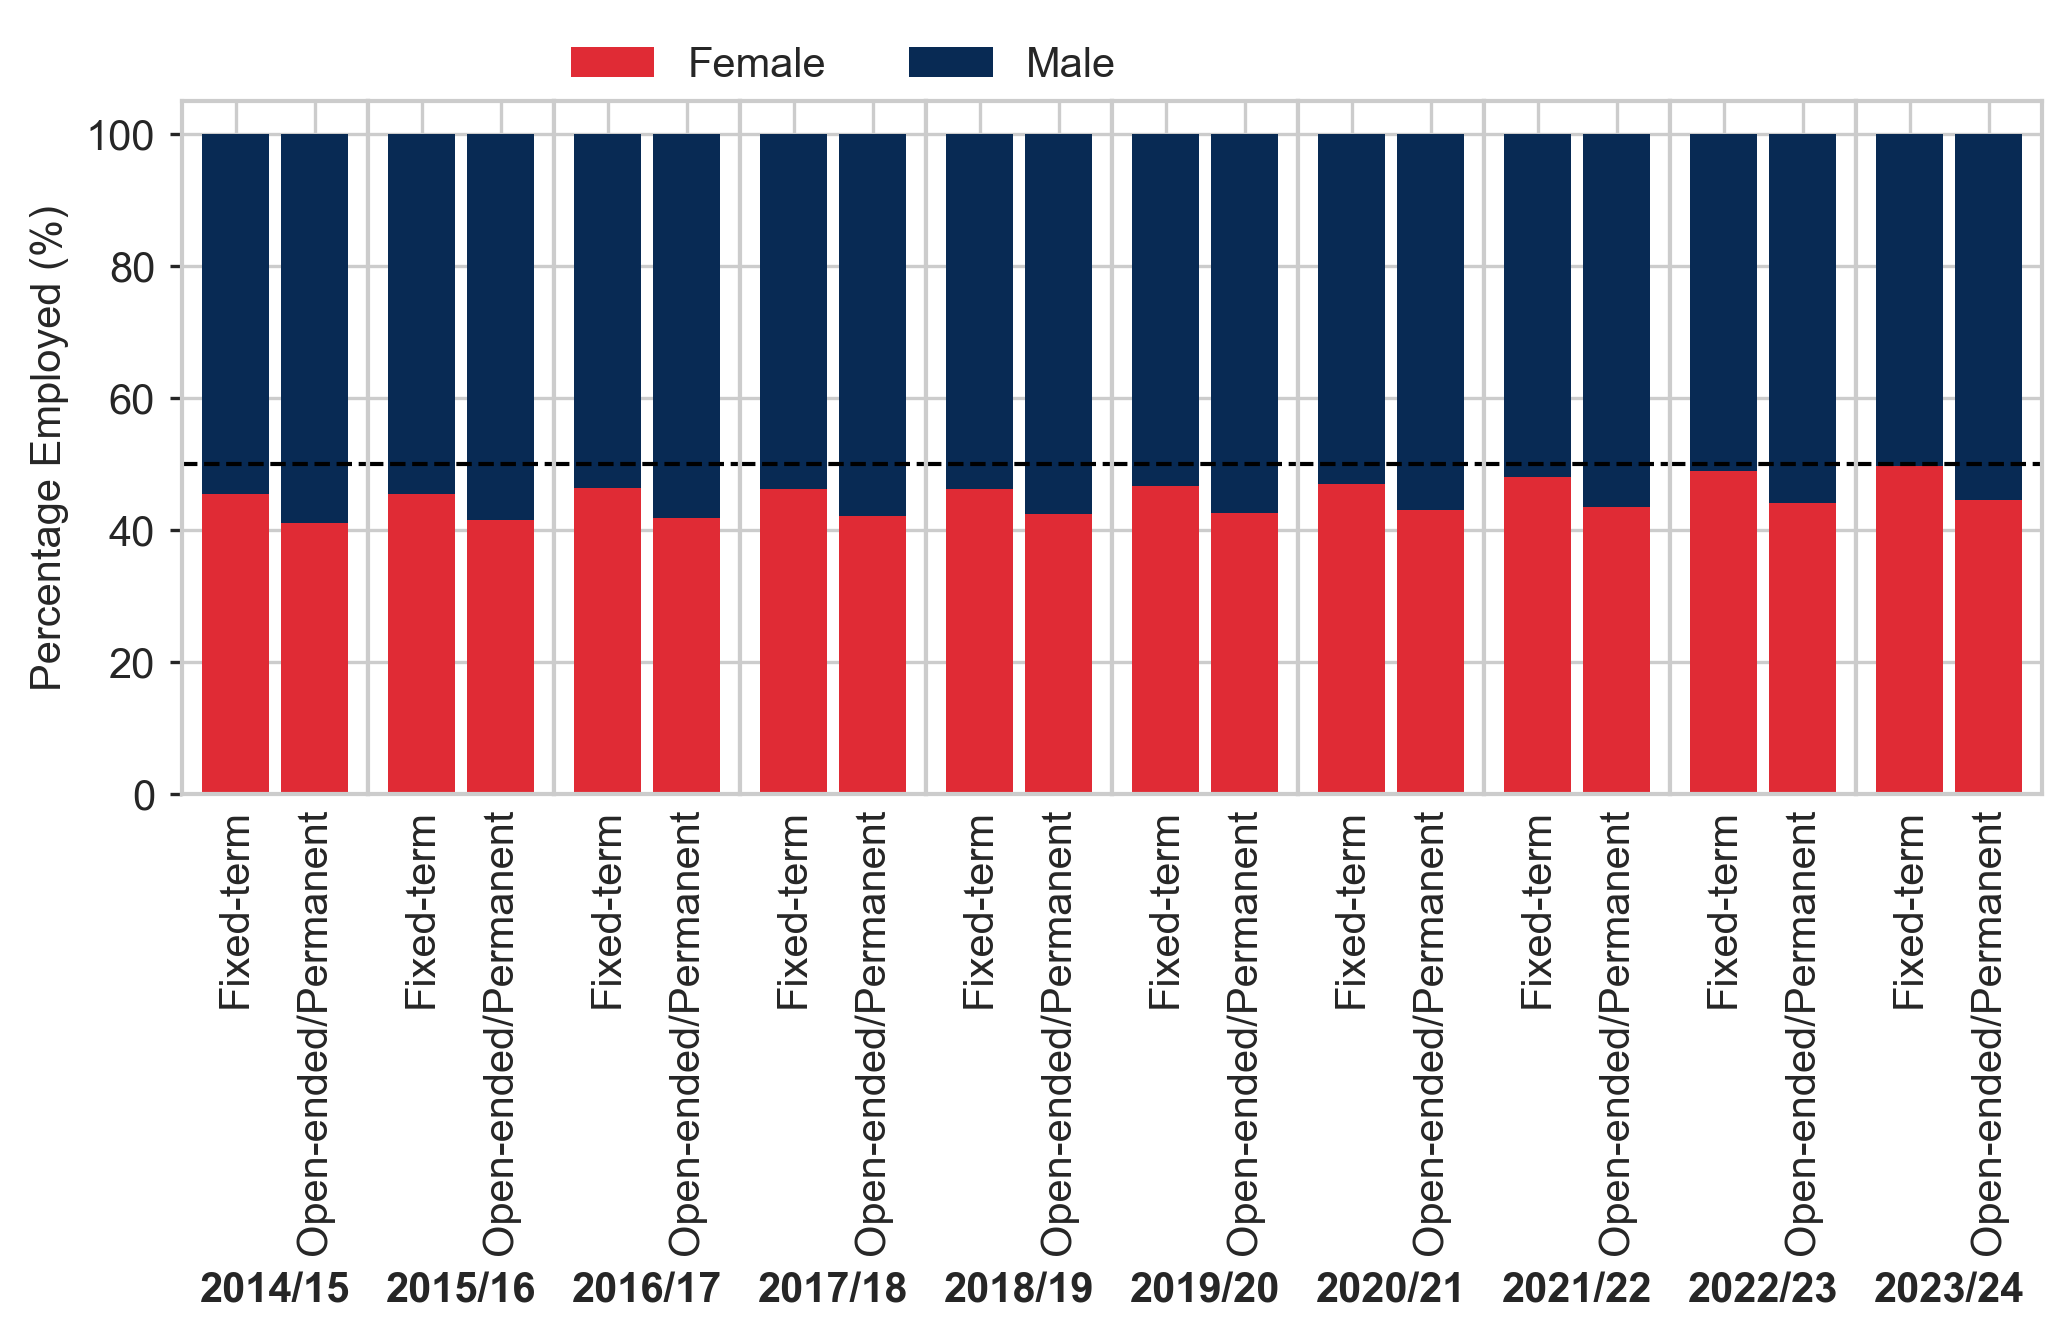

2014 total fixed-term staff = 41460
2024 total fixed-term staff = 39485
 Increase in fixed-term staff = -1975
++++++++++++++++++++++++++++++++++++
2014 total permanent staff = 103330
2024 total permanent staff = 116615
 Increase in permanent staff = 13285


In [47]:

#convert into percentages of total employed staff
df_normalised_employ_terms = df_gender_emply_trms.div(df_gender_emply_trms['Total academic staff'],axis=0) * 100

df_plotting = df_normalised_employ_terms[['Female','Male']].copy()

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3), dpi=300)

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=["#e02b35", "#082a54"]).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

for ax in axes:
    ax.axhline(50, lw=1, linestyle='--', color='black', alpha=1)

#axes[0].set_ylim(50,105)

# for ax in axes:
#     ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Percentage Employed (%)')
plt.legend(ncols=3, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_gender_employment_terms_percentages.svg'
fname_tiff = 'HESA_gender_employment_terms_percentages.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')


plt.show()

print(f'2014 total fixed-term staff = {df_gender_emply_trms['Total academic staff'].iloc[0::2].iloc[0]}')
print(f'2024 total fixed-term staff = {df_gender_emply_trms['Total academic staff'].iloc[0::2].iloc[-1]}')
print('======================')
print(f' Increase in fixed-term staff = {df_gender_emply_trms['Total academic staff'].iloc[0::2].iloc[-1] - df_gender_emply_trms['Total academic staff'].iloc[0::2].iloc[0]}')
print('++++++++++++++++++++++++++++++++++++')
print(f'2014 total permanent staff = {df_gender_emply_trms['Total academic staff'].iloc[1::2].iloc[0]}')
print(f'2024 total permanent staff = {df_gender_emply_trms['Total academic staff'].iloc[1::2].iloc[-1]}')
print('======================')
print(f' Increase in permanent staff = {df_gender_emply_trms['Total academic staff'].iloc[1::2].iloc[-1] - df_gender_emply_trms['Total academic staff'].iloc[1::2].iloc[0]}')

### HESA Table 5

### Disability

In [ ]:
# read in staff ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\table-5.csv"
df = pd.read_csv(path, header=22)

# Filter for specific staff data (can control of various aspects at this point)
filtered_df = df[df['Academic employment function'].str.contains('Research only|Both teaching and research', case=False, na=False) &
                 df['Sex'].str.contains('All', case=False, na=False) &
                 df['Mode of employment'].str.contains('All', case=False, na=False) &
                 df['Country of HE provider'].str.contains('All', case=False, na=False) &
                 df['Terms of employment'].str.contains('Fixed-term|Open-ended/Permanent', case=False, na=False) &
                 df['Nationality marker'].str.contains('All', case=False, na=False)]

#filtered_df
# # Pivot the DataFrame
df_pivot = filtered_df.pivot(index=['Academic year','Terms of employment','Academic employment function'], columns='Disability', values='Number')


df_disability_emply_trms = df_pivot[['Total academic staff','Total of known disability status', 'Total staff with a disability', 'Unknown', 'No known impairment, health condition or learning difference']].groupby(level=[0,1]).sum().copy()

#convert into percentages of total employed staff
df_normalised = df_disability_emply_trms.div(df_disability_emply_trms['Total academic staff'], axis=0) * 100
df_disability = df_normalised[['No known impairment, health condition or learning difference','Unknown','Total staff with a disability']].copy()




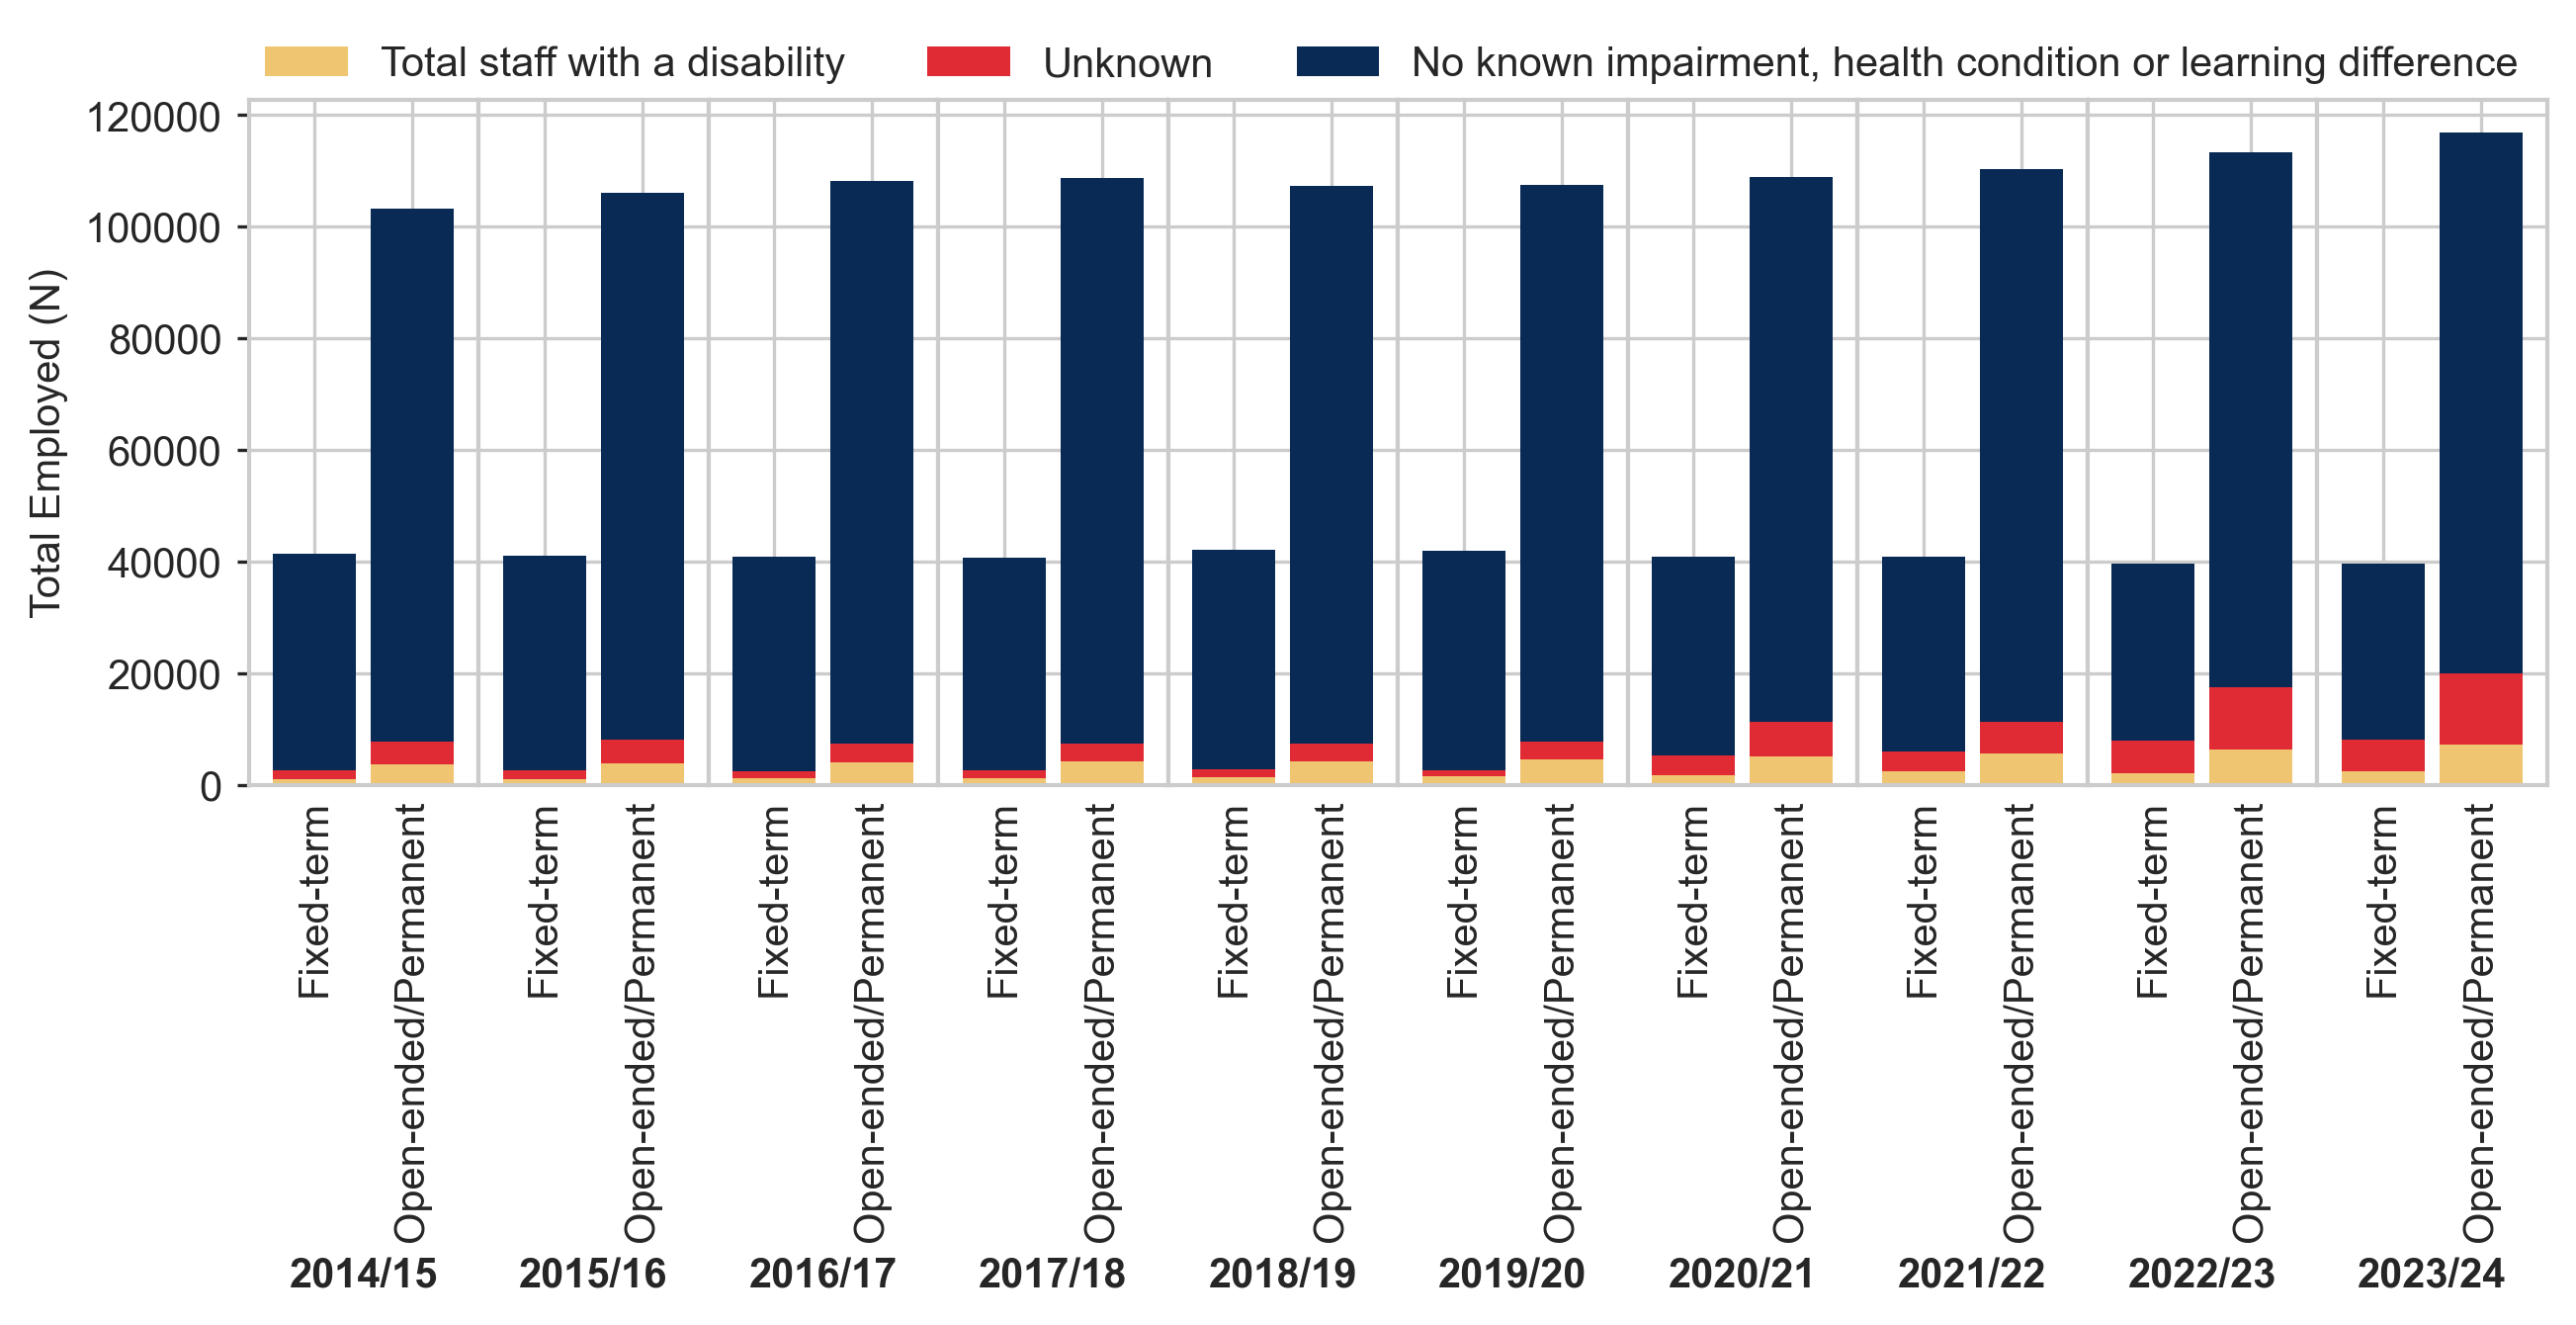

In [36]:
#======================
# plot raw numbers

df_plotting = df_disability_emply_trms[['Total staff with a disability','Unknown','No known impairment, health condition or learning difference']]

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(10, 3), dpi=300  )

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors[3:]).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

axes[0].set_ylabel('Total Employed (N)')
plt.legend(ncols=3, frameon=False, loc=(-9,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_disability_employment_terms_N.svg'
fname_tiff = 'HESA_disability_employment_terms_N.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()


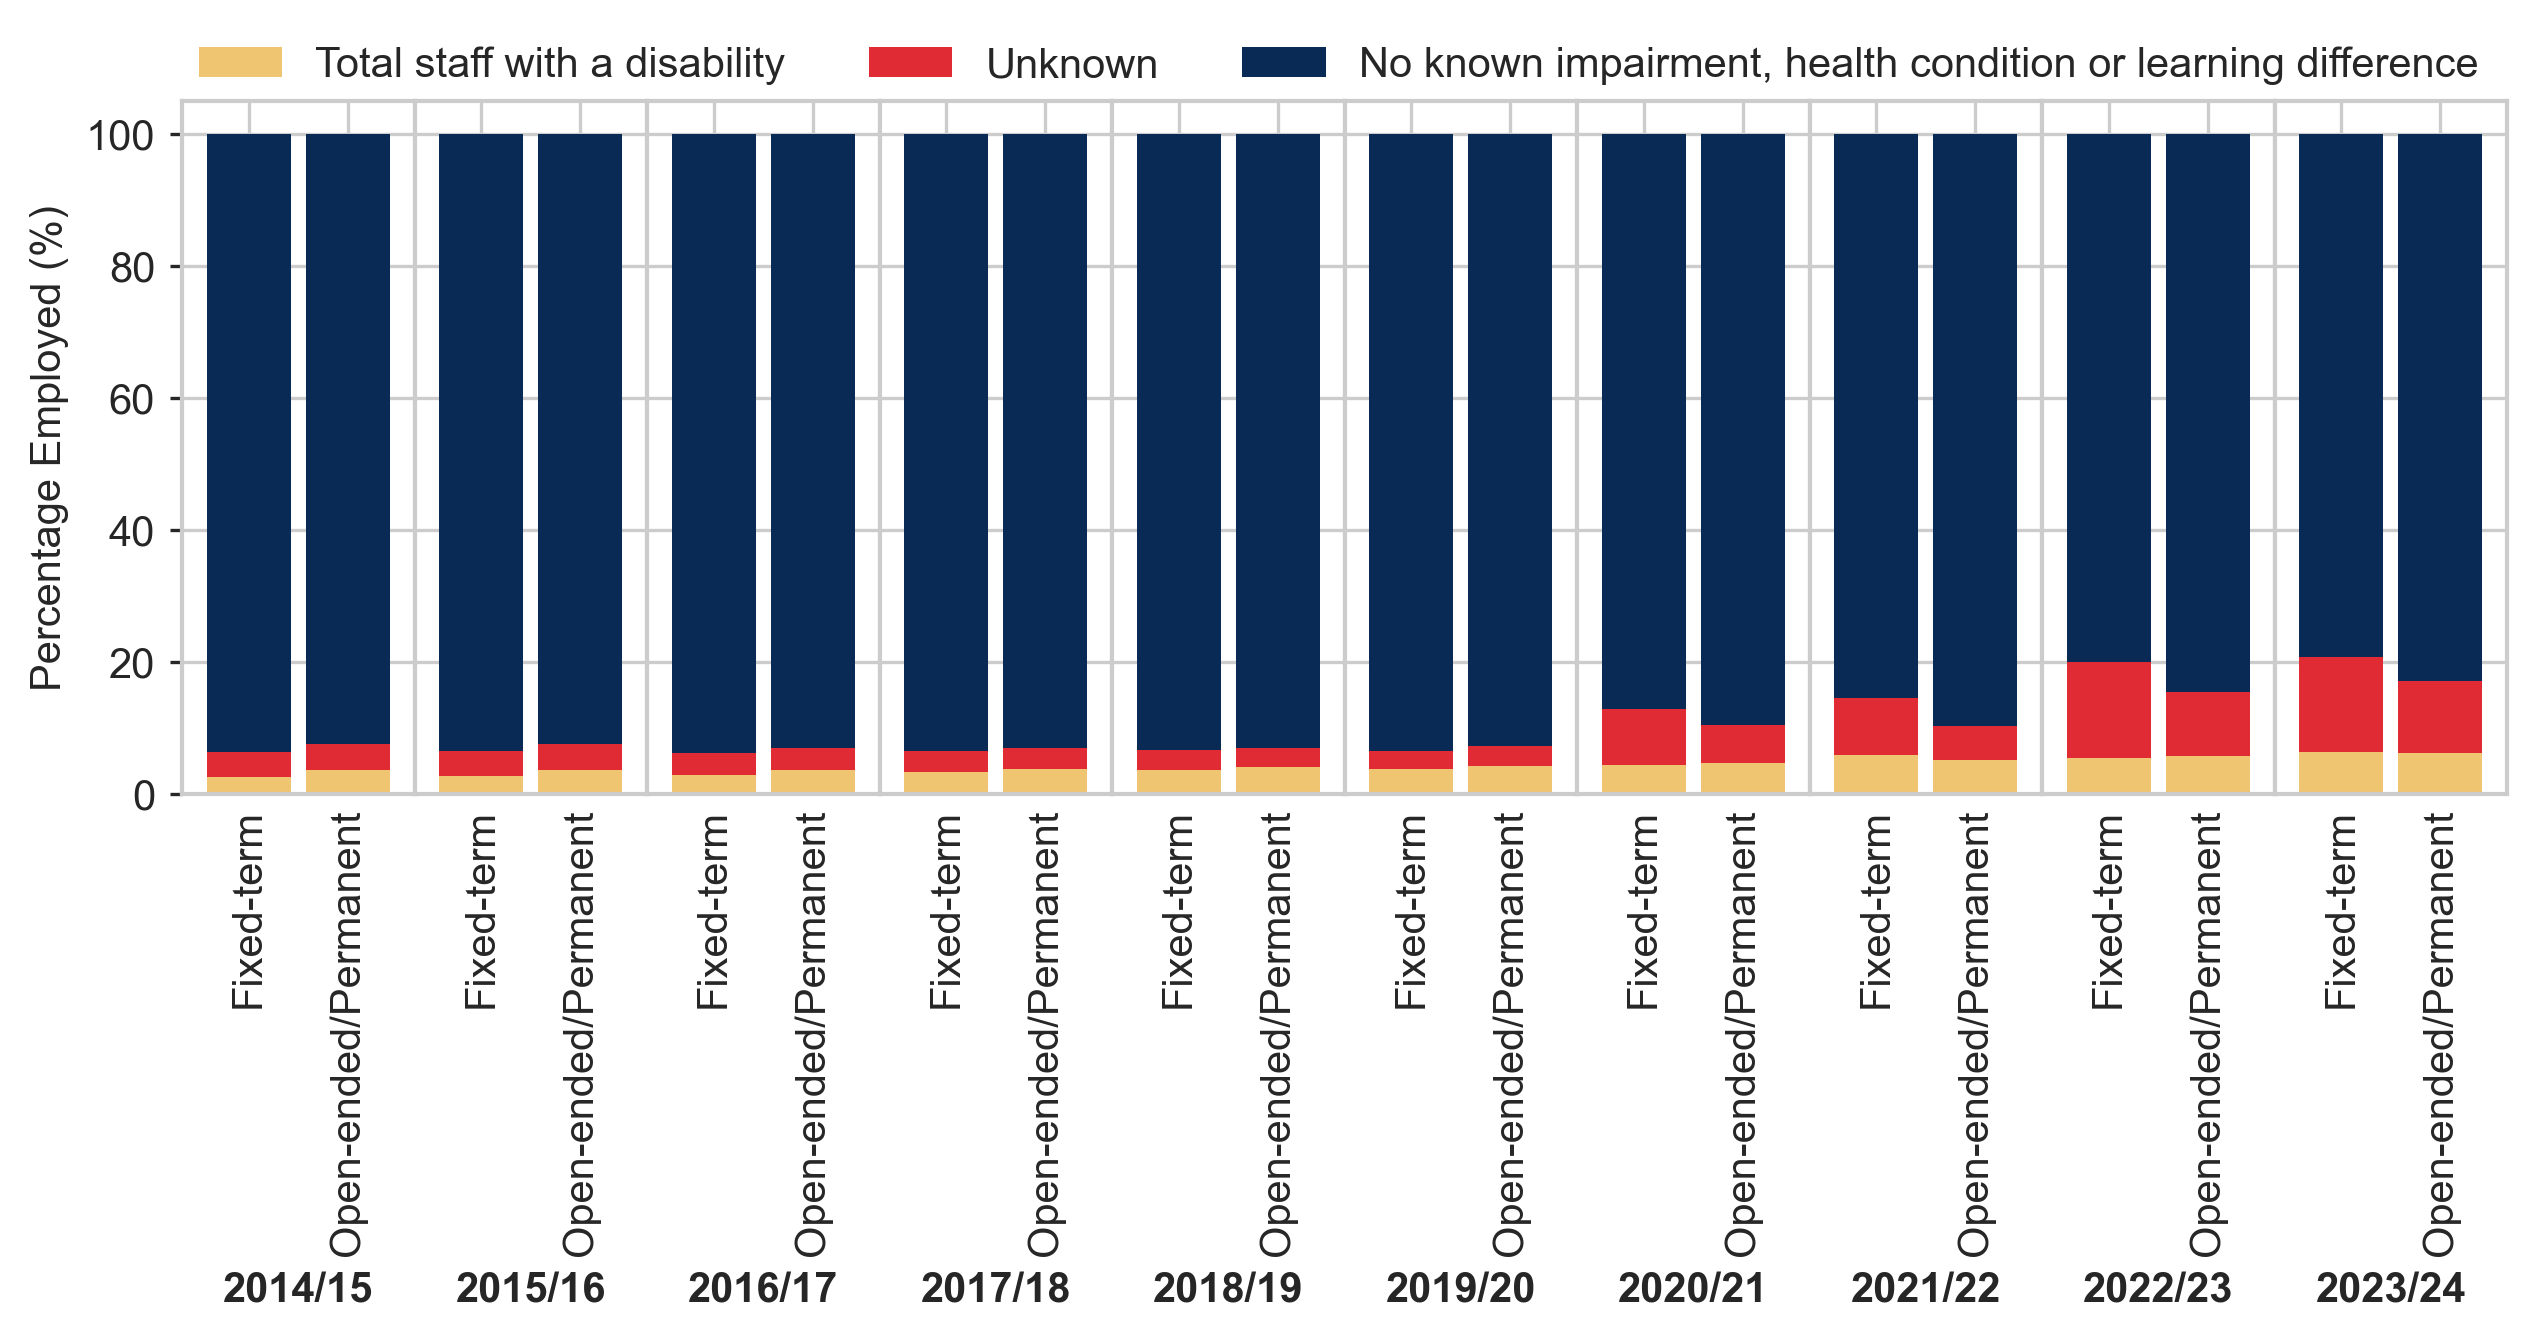

In [37]:
#======================
# plot percentage breakdowns


df_plotting = df_disability[['Total staff with a disability','Unknown','No known impairment, health condition or learning difference']]

n_subplots = len(df_plotting.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(10, 3), dpi=300  )

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors[3:]).set_xlabel(x, weight='bold'), graph))

for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)
axes[0].tick_params(axis='y', length=3)

axes[0].set_ylabel('Percentage Employed (%)')
plt.legend(ncols=3, frameon=False, loc=(-9,1))
fig.subplots_adjust(wspace=0)

fname = 'HESA_disability_employment_terms_percentages.svg'
fname_tiff = 'HESA_disability_employment_terms_percentages.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')


plt.show()


### UKRI EDI data

### Ethnicity

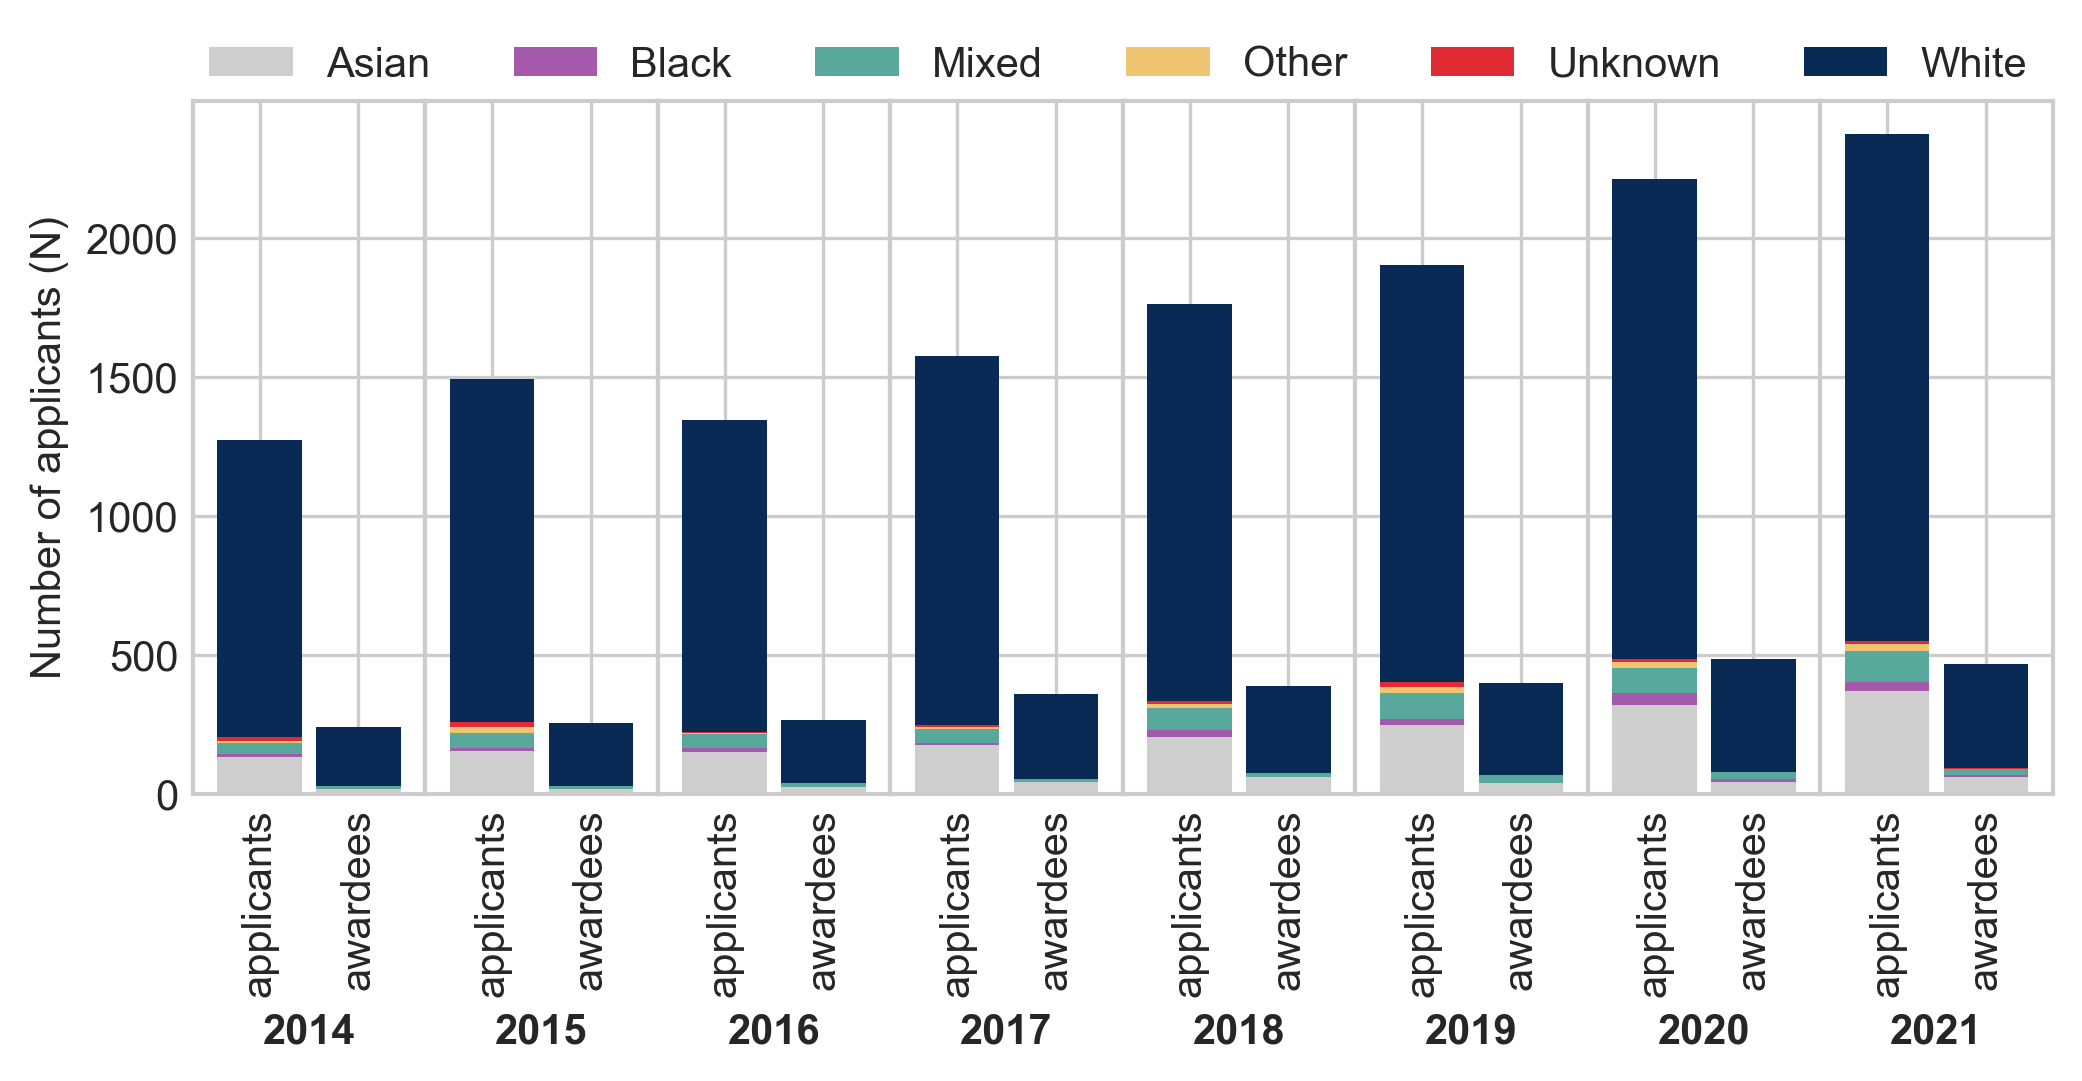

Average number of applicants per awardee = 4.94


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (N)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (N)'])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # get UKRI (all) data

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])
ukri_applications

#====================================
# Plotting numbers of applicants

df_plotting = ukri_applications[[ 'Asian','Black','Mixed','Other','Unknown','White']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3),dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Number of applicants (N)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_breakdown_N.svg'
fname_tiff = 'UKRI_breakdown_N.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')


plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

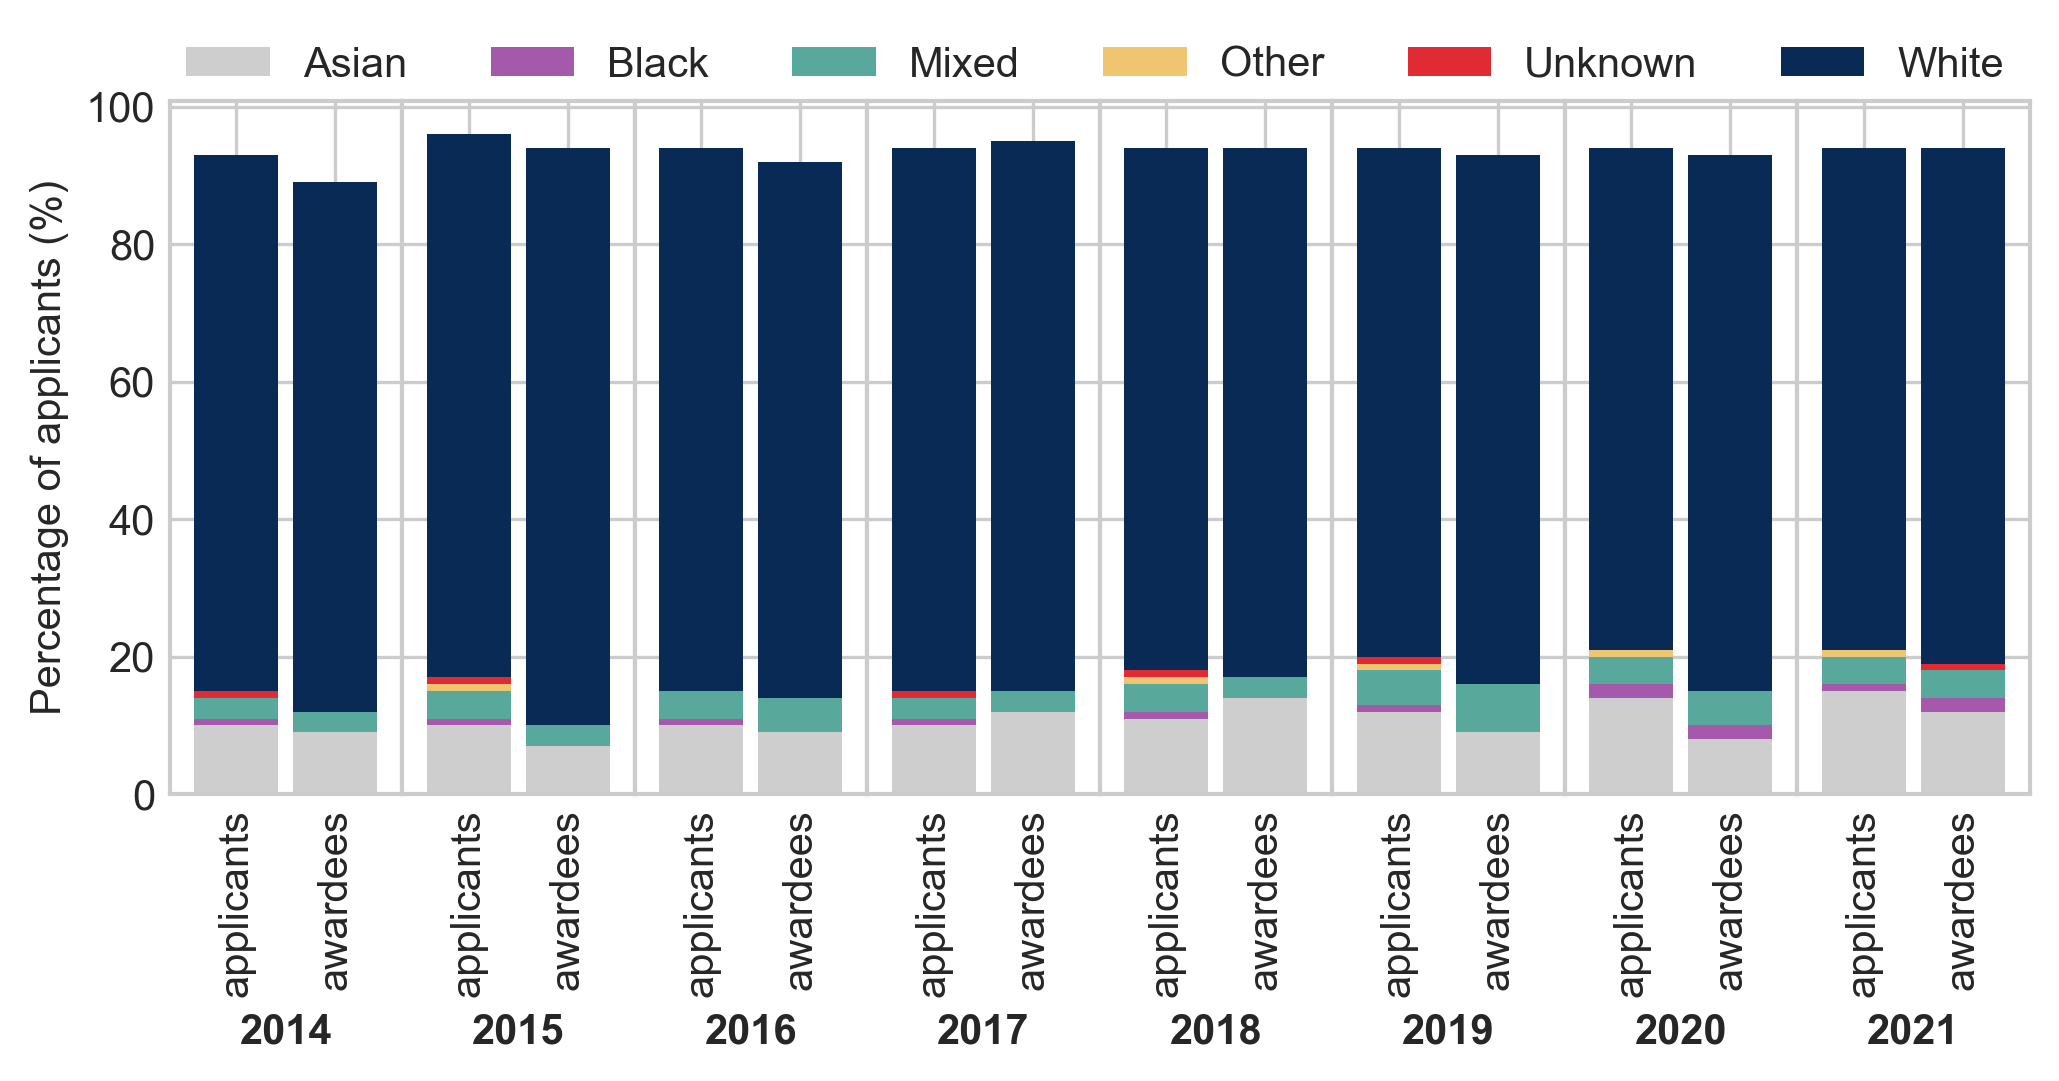

Average number of applicants per awardee = 1.01


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # get UKRI (all) data

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])
ukri_applications

#====================================
# Plotting numbers of applicants

df_plotting = ukri_applications[[ 'Asian','Black','Mixed','Other','Unknown','White']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3), dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Percentage of applicants (%)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_breakdown_percentage.svg'
fname_tiff = 'UKRI_breakdown_percentage.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

C:\Users\ct832900\AppData\Local\Temp\ipykernel_284\1466186787.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(np.linspace(0,100,5).astype(int), color='white')


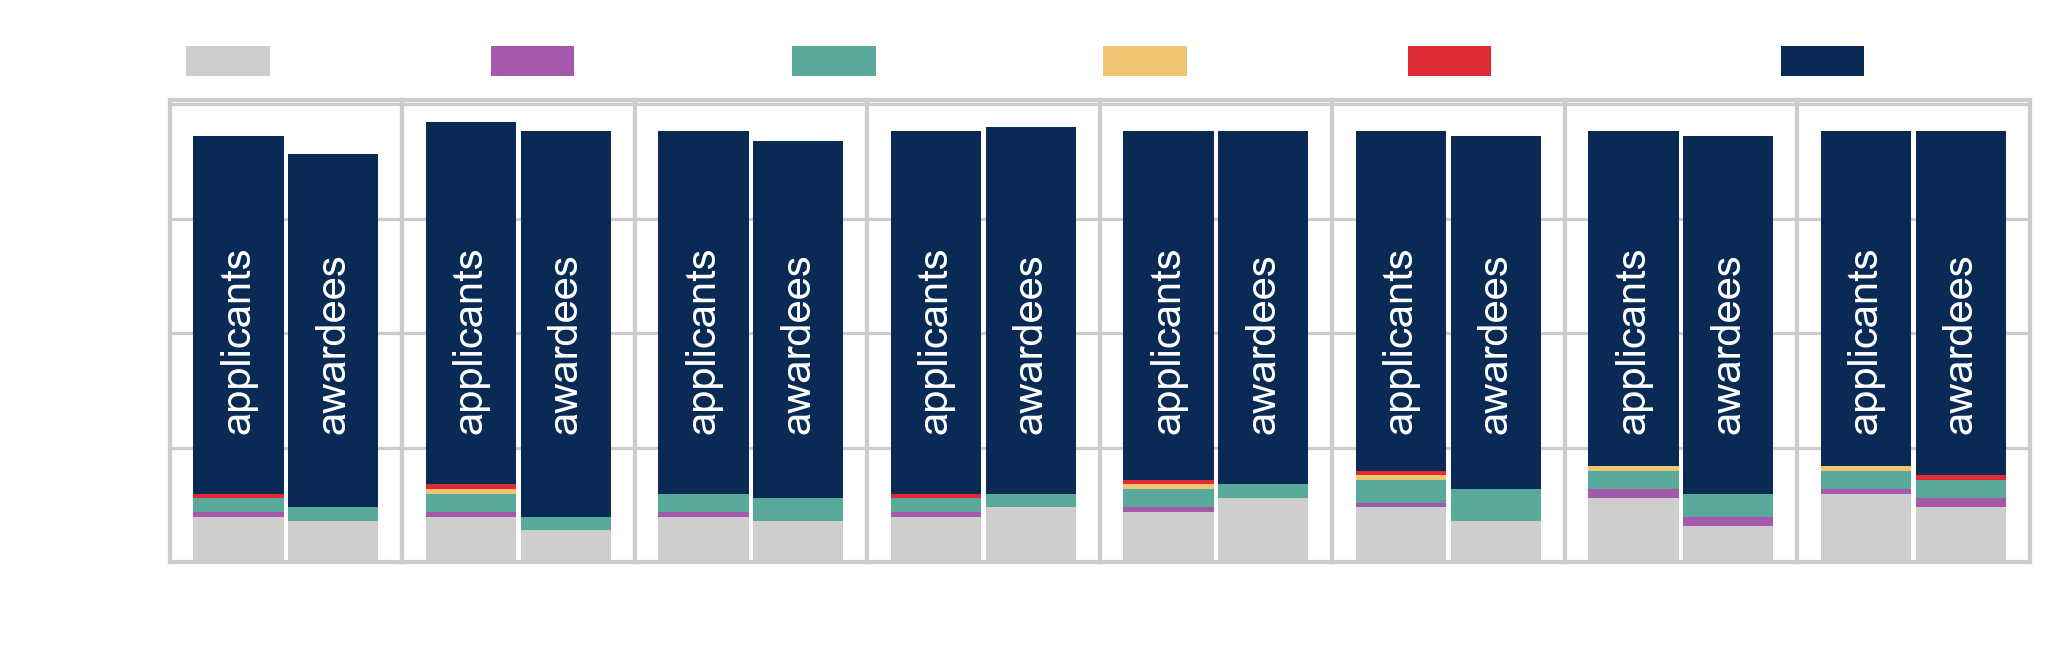

Average number of applicants per awardee = 1.01


In [ ]:
#===========================================
# figure formatting for graphical abstract


# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # get UKRI (all) data

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])
ukri_applications

#====================================
# Plotting numbers of applicants

df_plotting = ukri_applications[[ 'Asian','Black','Mixed','Other','Unknown','White']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 2), dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.95, color=colors).set_xlabel(x, weight='bold', color='white'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_yticklabels(np.linspace(0,100,5).astype(int), color='white')

for ax in axes:
    ax.set_xticks([])
    ax.annotate('applicants', (-0.2,30), color='white', rotation=90)
    ax.annotate('awardees', (0.8,30), color='white', rotation=90)


axes[0].set_ylabel('Percentage of applicants (%)', color='white')
plt.legend(ncols=6, frameon=False, loc=(-7,1), labelcolor='white')
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_breakdown_percentage_squashed.svg'
fname_tiff = 'UKRI_breakdown_percentage.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
#plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

### Gender

In [40]:
### Custom colors
colors_r = [
    "#e02b35",  # red
    "#082a54",  # dark blue
    "#59a89c",  # teal
    "#f0c571",  # gold
]

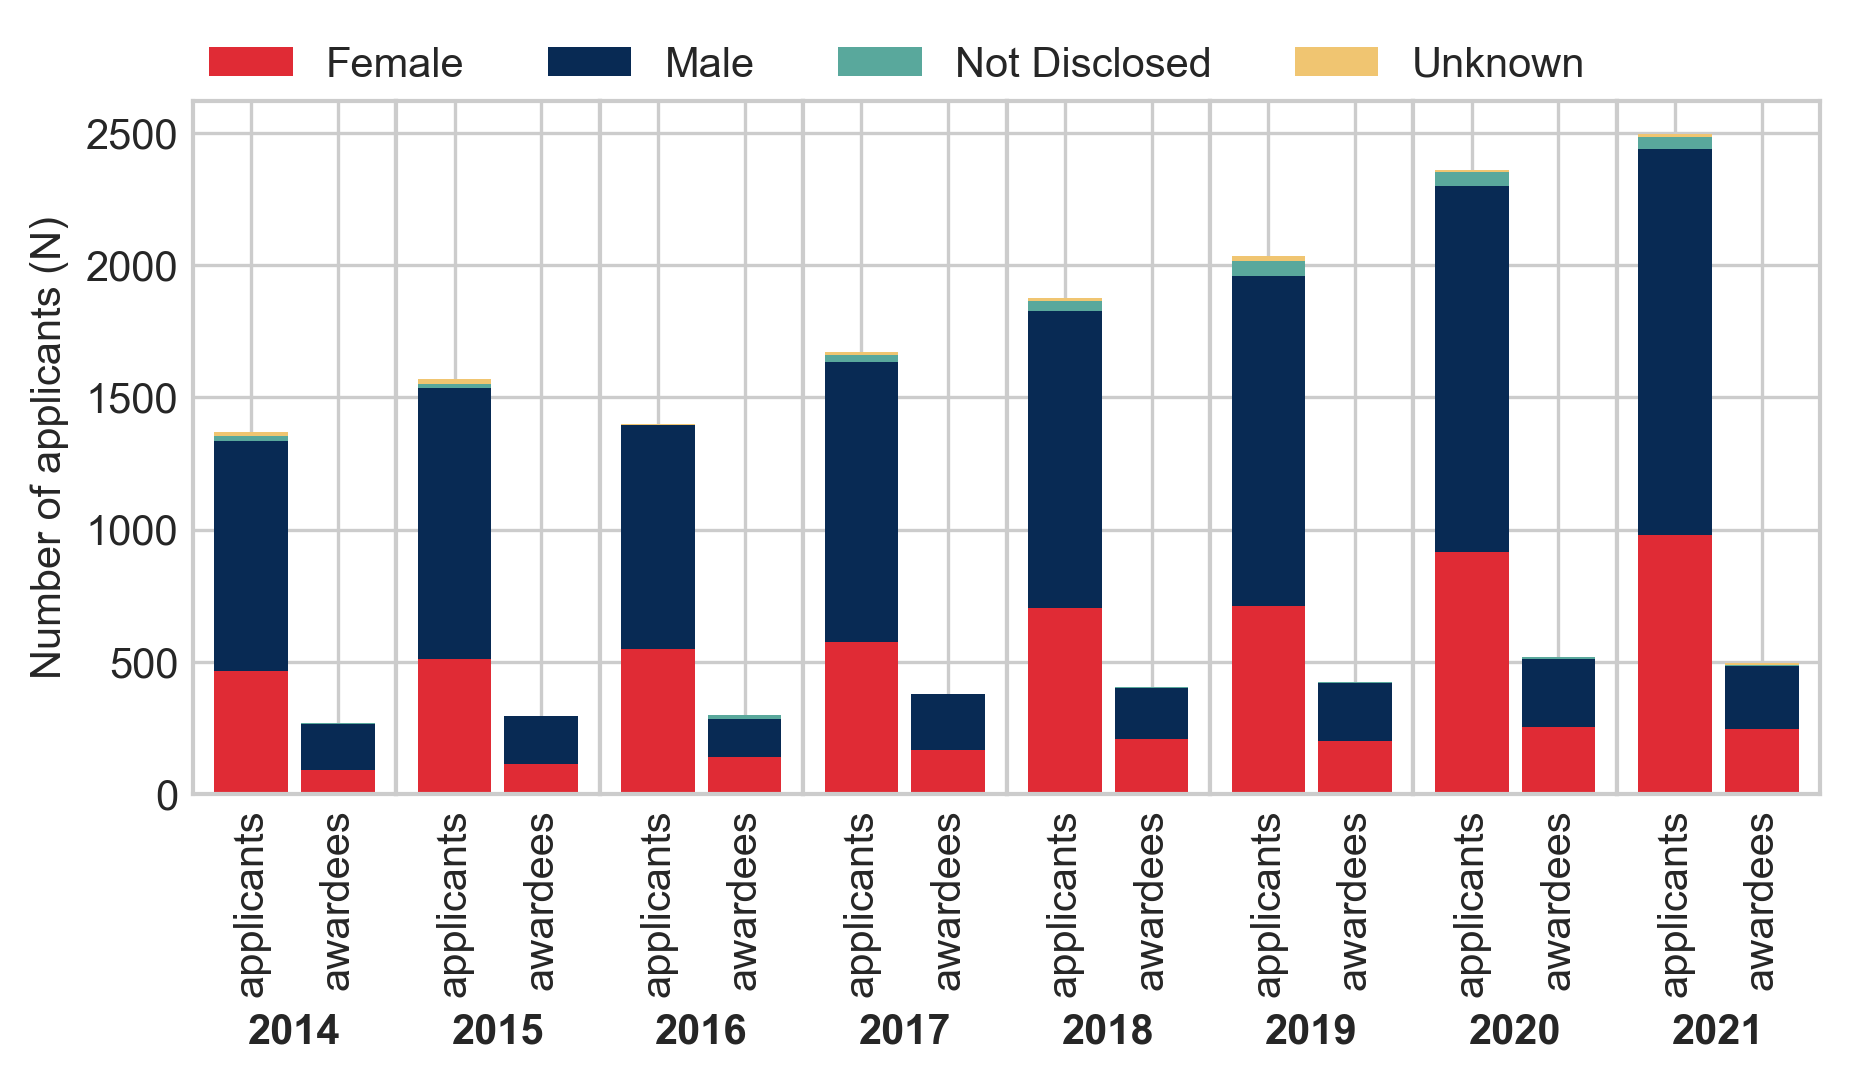

Average number of applicants per awardee = 4.81


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data_gender.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (N)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (N)'])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # UKRI (all) key

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])


#==================================
# plotting

df_plotting = ukri_applications[['Female','Male','Not Disclosed','Unknown']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(7, 3), dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors_r).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Number of applicants (N)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_gender_breakdown_N.svg'
fname_tiff = 'UKRI_gender_breakdown_N.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300, bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300, bbox_inches='tight')


plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

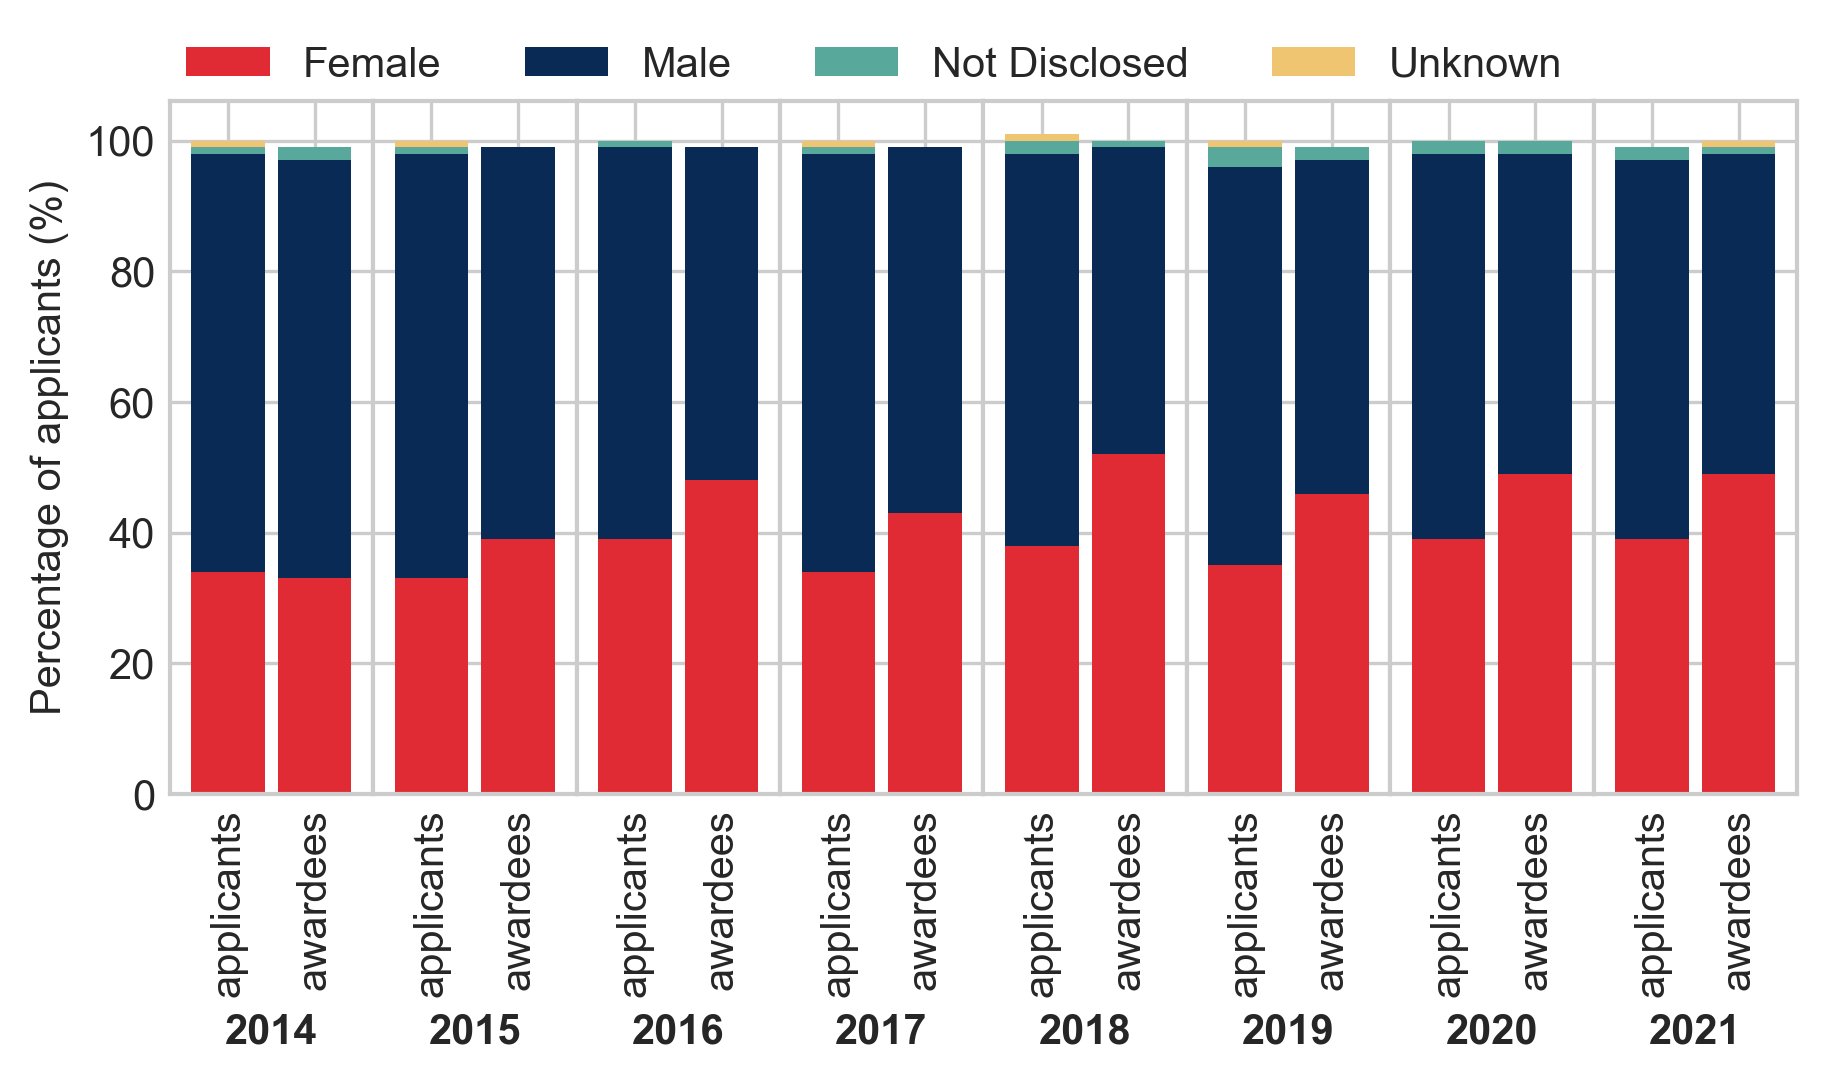

Average number of applicants per awardee = 1.01


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data_gender.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # UKRI (all) key

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])


#==================================
# plotting

df_plotting = ukri_applications[['Female','Male','Not Disclosed','Unknown']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(7, 3), dpi=300)  # width, height
graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors_r).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Percentage of applicants (%)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_gender_breakdown_percentage.svg'
fname_tiff = 'UKRI_gender_breakdown_percentage.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300, bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300, bbox_inches='tight')


plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

### Disability

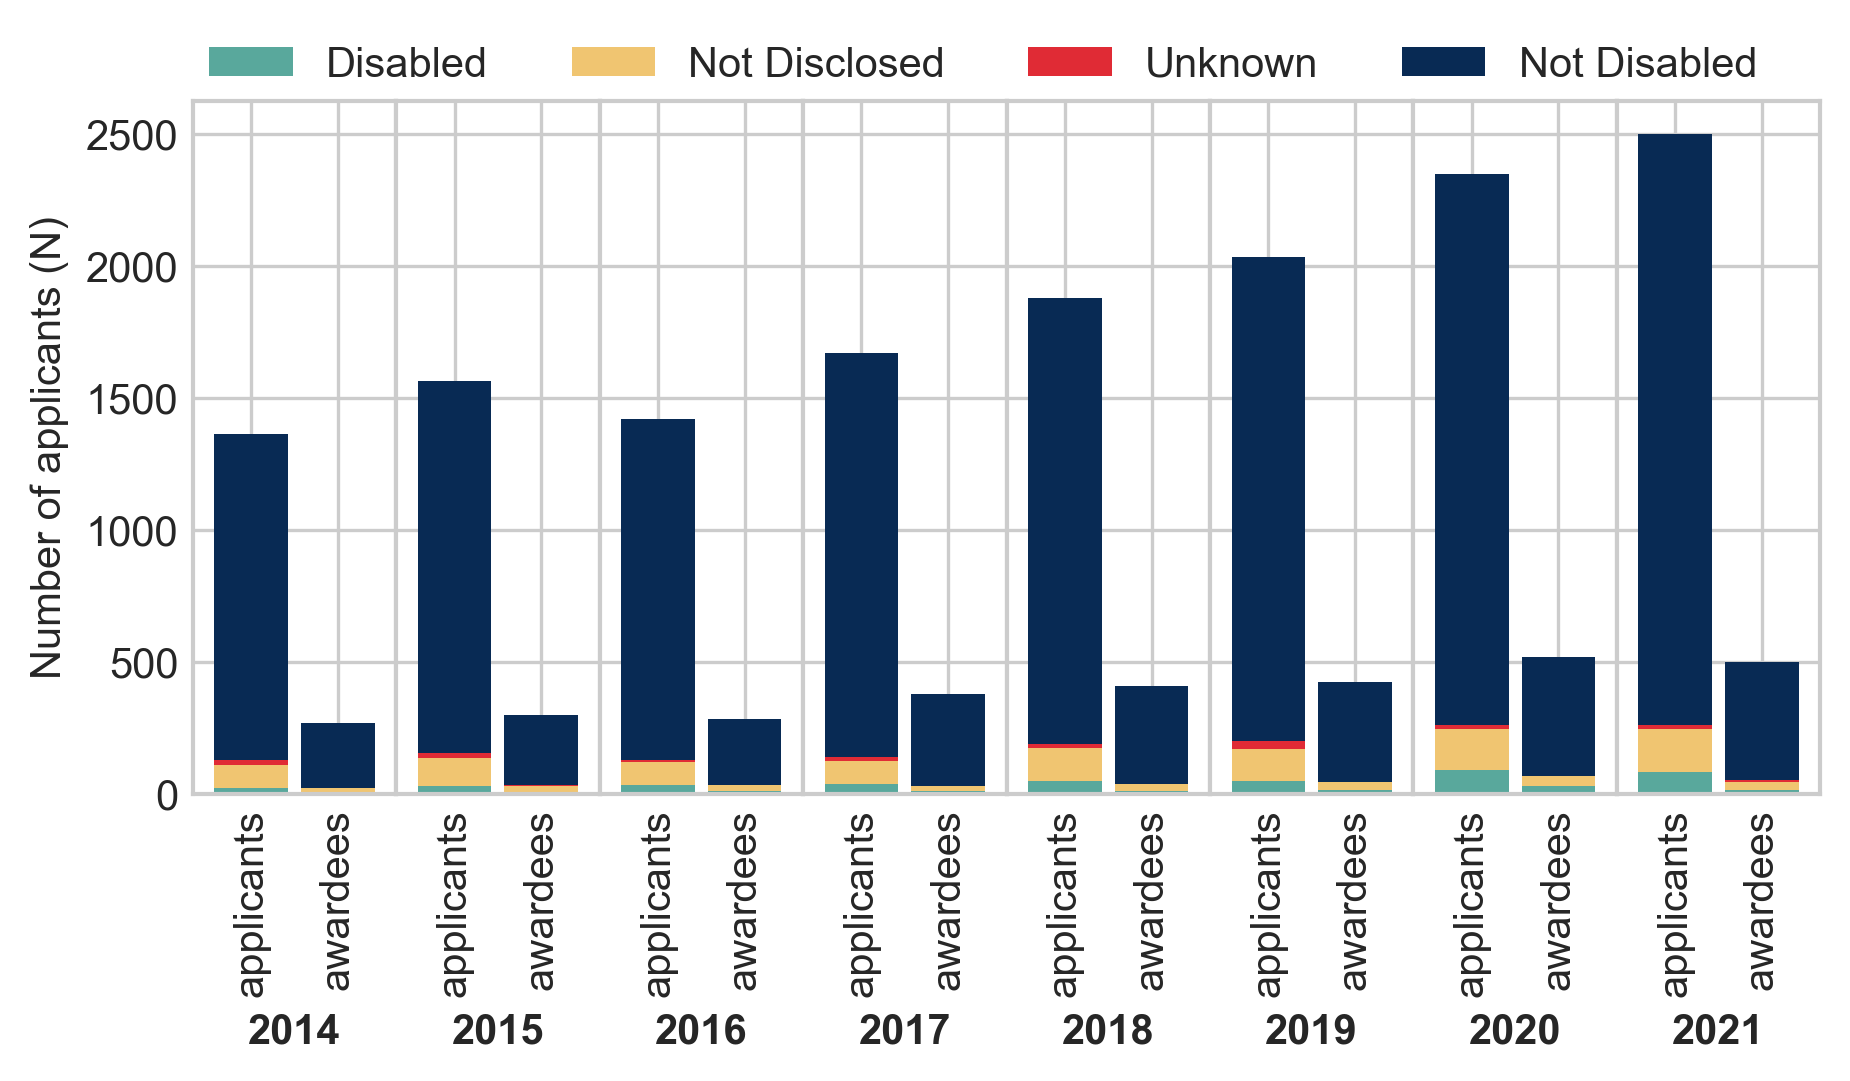

Average number of applicants per awardee = 4.82


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data_disability.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (N)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (N)'])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])


council_label = council_keys[-1]

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])
ukri_applications


#df_plotting = ukri_applications[['Female','Male','Not Disclosed','Unknown']].copy()
df_plotting = ukri_applications[['Disabled','Not Disclosed','Unknown','Not Disabled']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(7, 3),dpi=300)  # width, height

plt.style.use('seaborn-v0_8-colorblind')
graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors[2:]).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Number of applicants (N)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)


fname = 'UKRI_disablity_breakdown_N.svg'
fname_tiff = 'UKRI_disability_breakdown_N.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300, bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300, bbox_inches='tight')


plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')


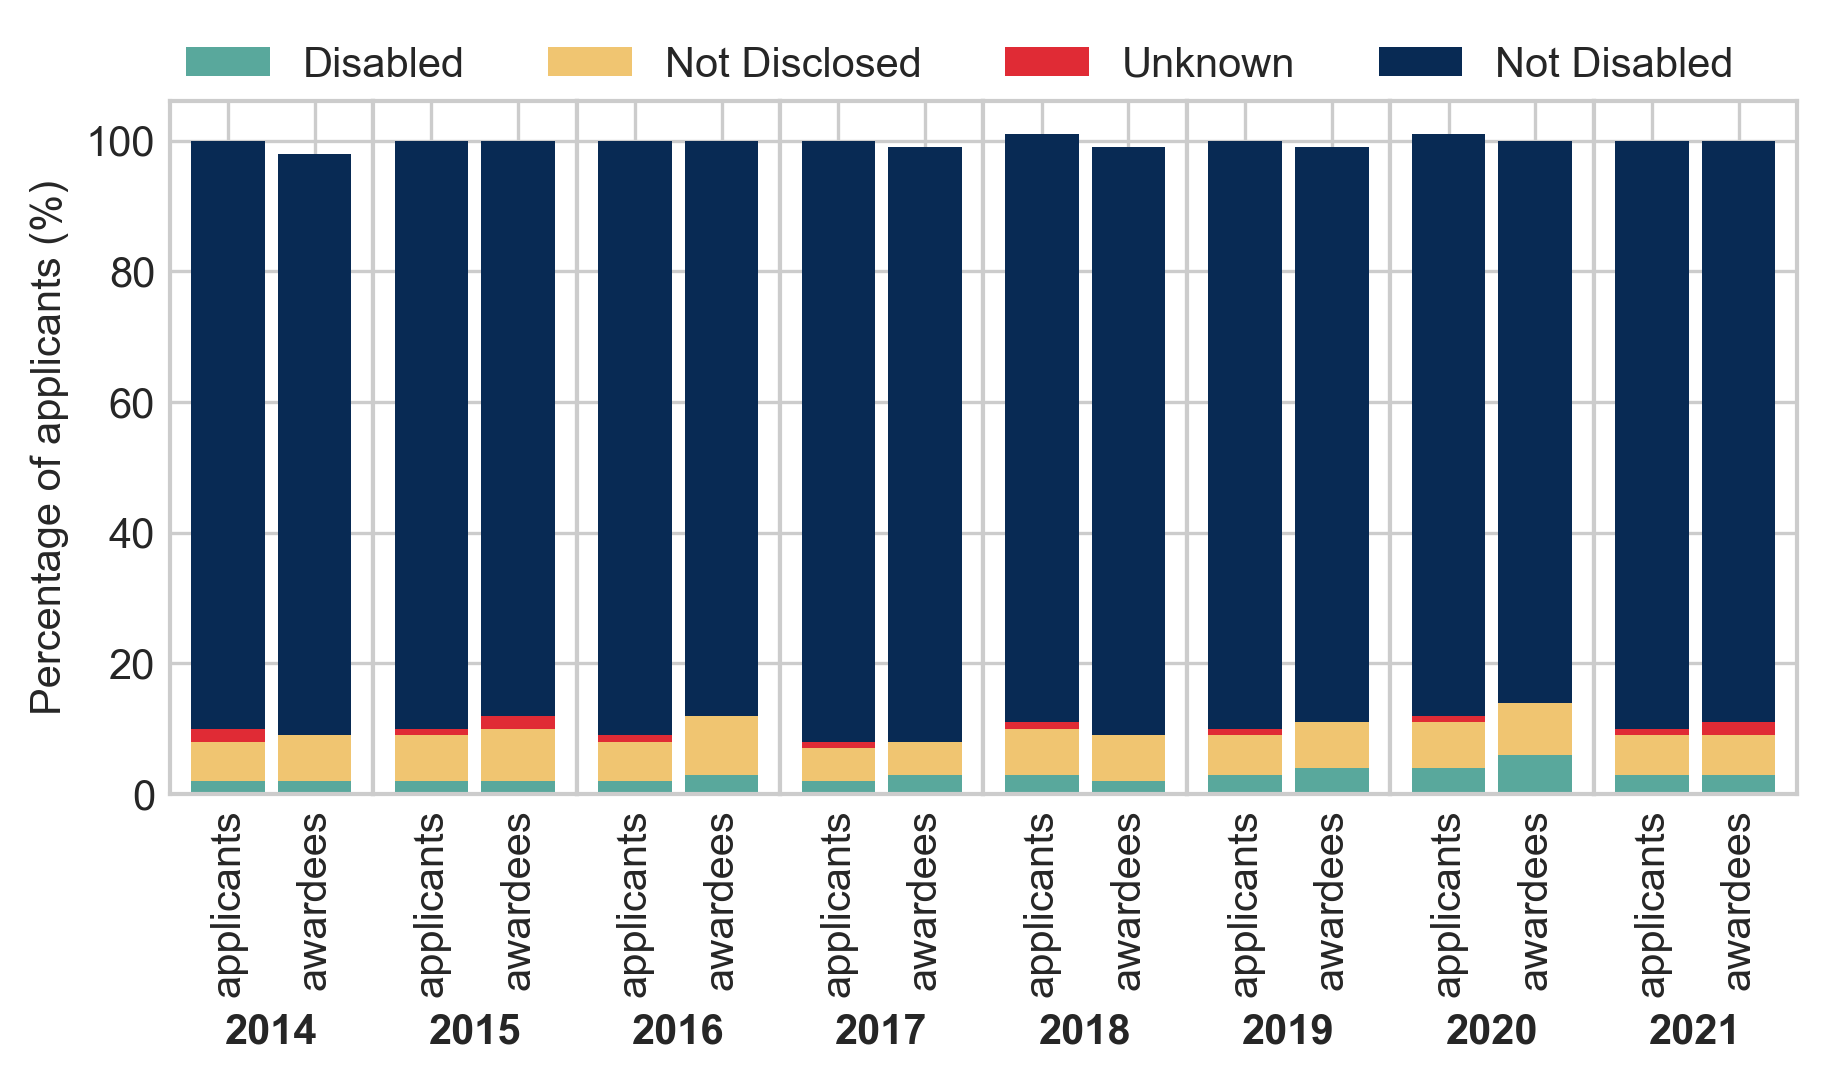

Average number of applicants per awardee = 1.01


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data_disability.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])


council_label = council_keys[-1] # ukri (all) key

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])
ukri_applications

#=============================
# plot percentage breakdown

#df_plotting = ukri_applications[['Female','Male','Not Disclosed','Unknown']].copy()
df_plotting = ukri_applications[['Disabled','Not Disclosed','Unknown','Not Disabled']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(7, 3),dpi=300)  # width, height

plt.style.use('seaborn-v0_8-colorblind')
graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors[2:]).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Percentage of applicants (%)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_disability_breakdown_percentage.svg'
fname_tiff = 'UKRI_disability_breakdown_percentage.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300, bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300, bbox_inches='tight')


plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')


### UKRI PI data

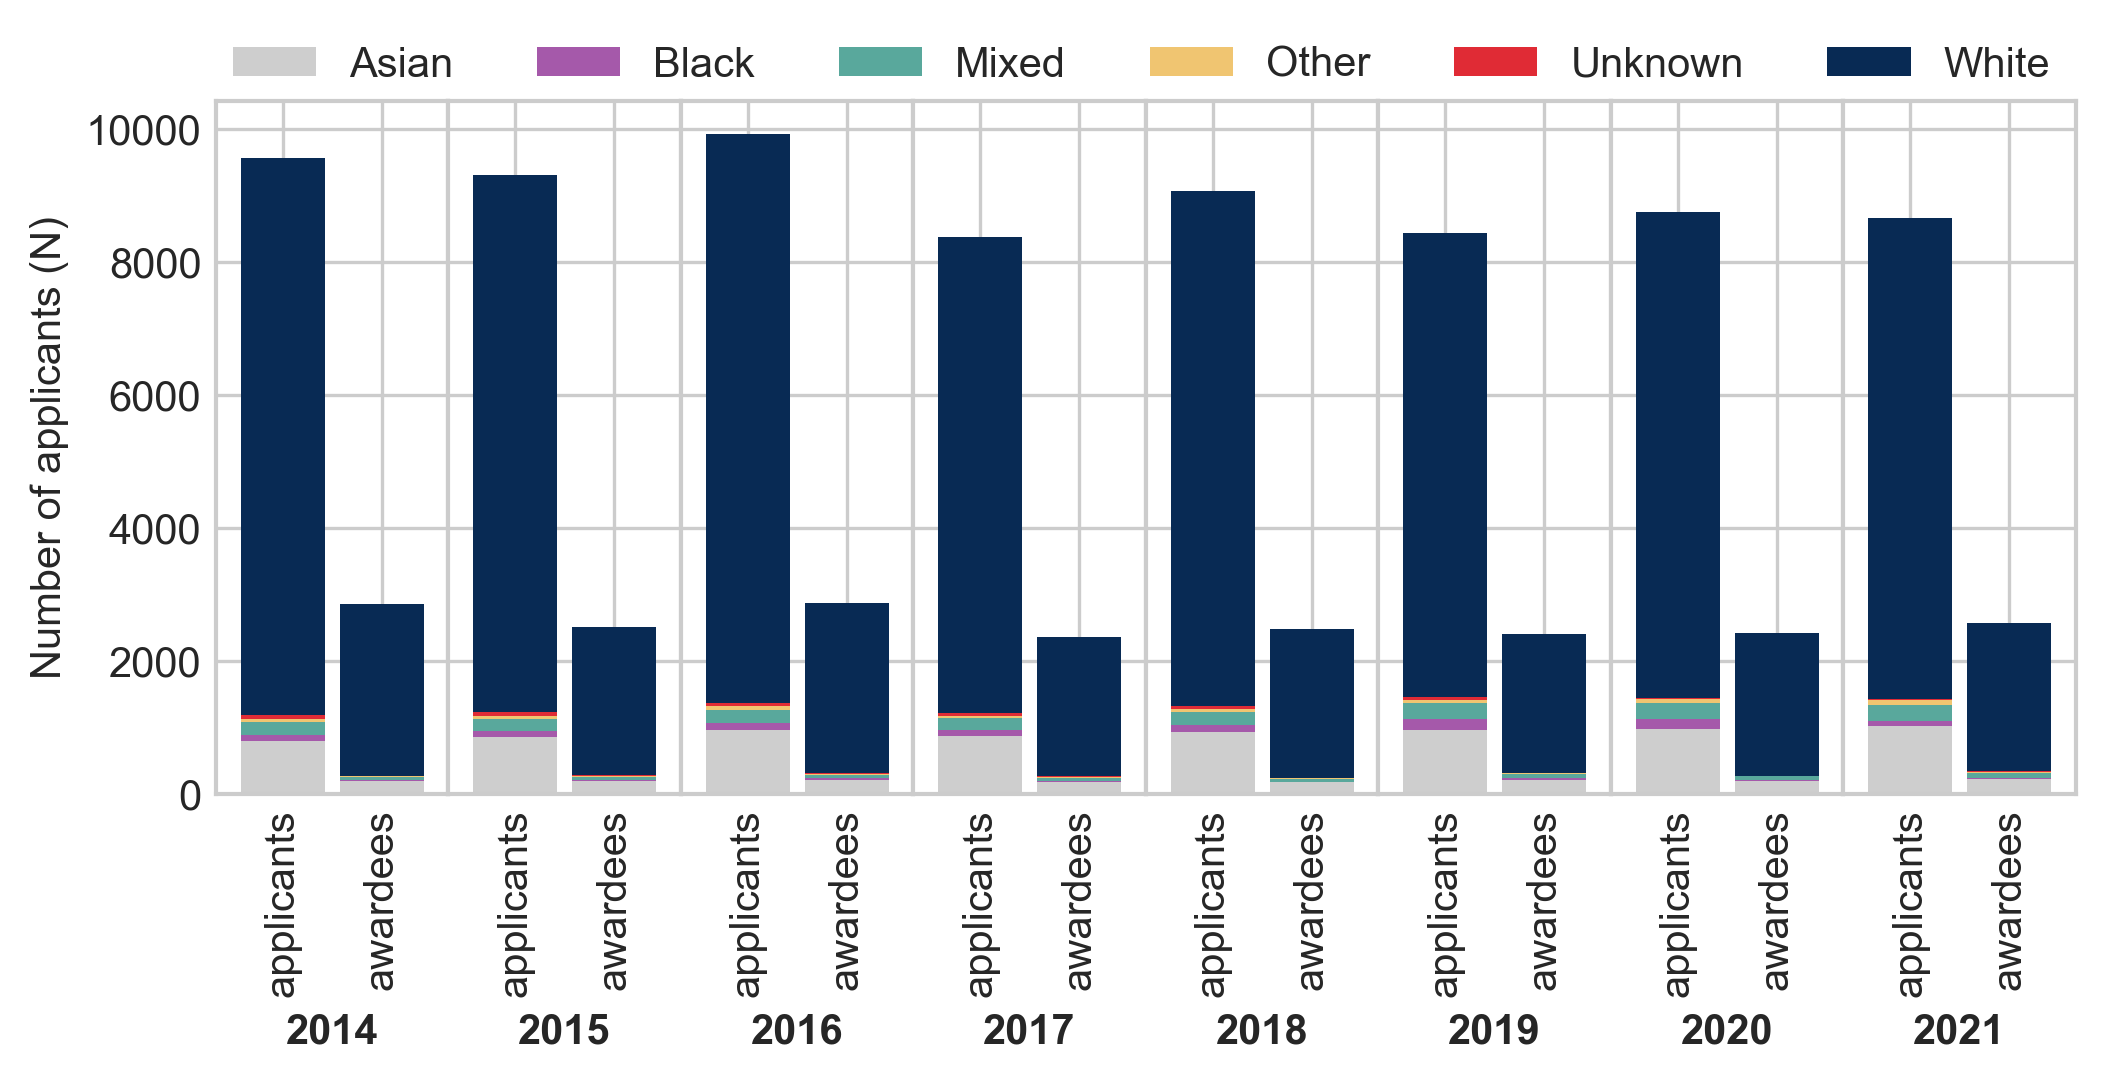

Average number of applicants per awardee = 3.51


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\PI_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (N)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (N)'])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # get UKRI (all) data

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0).astype(float)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])


#====================================
# Plotting numbers of applicants

df_plotting = ukri_applications[[ 'Asian','Black','Mixed','Other','Unknown','White']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3),dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Number of applicants (N)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)
fname = 'UKRI_PI_breakdown_N.svg'
fname_tiff = 'UKRI_PI_breakdown_N.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')

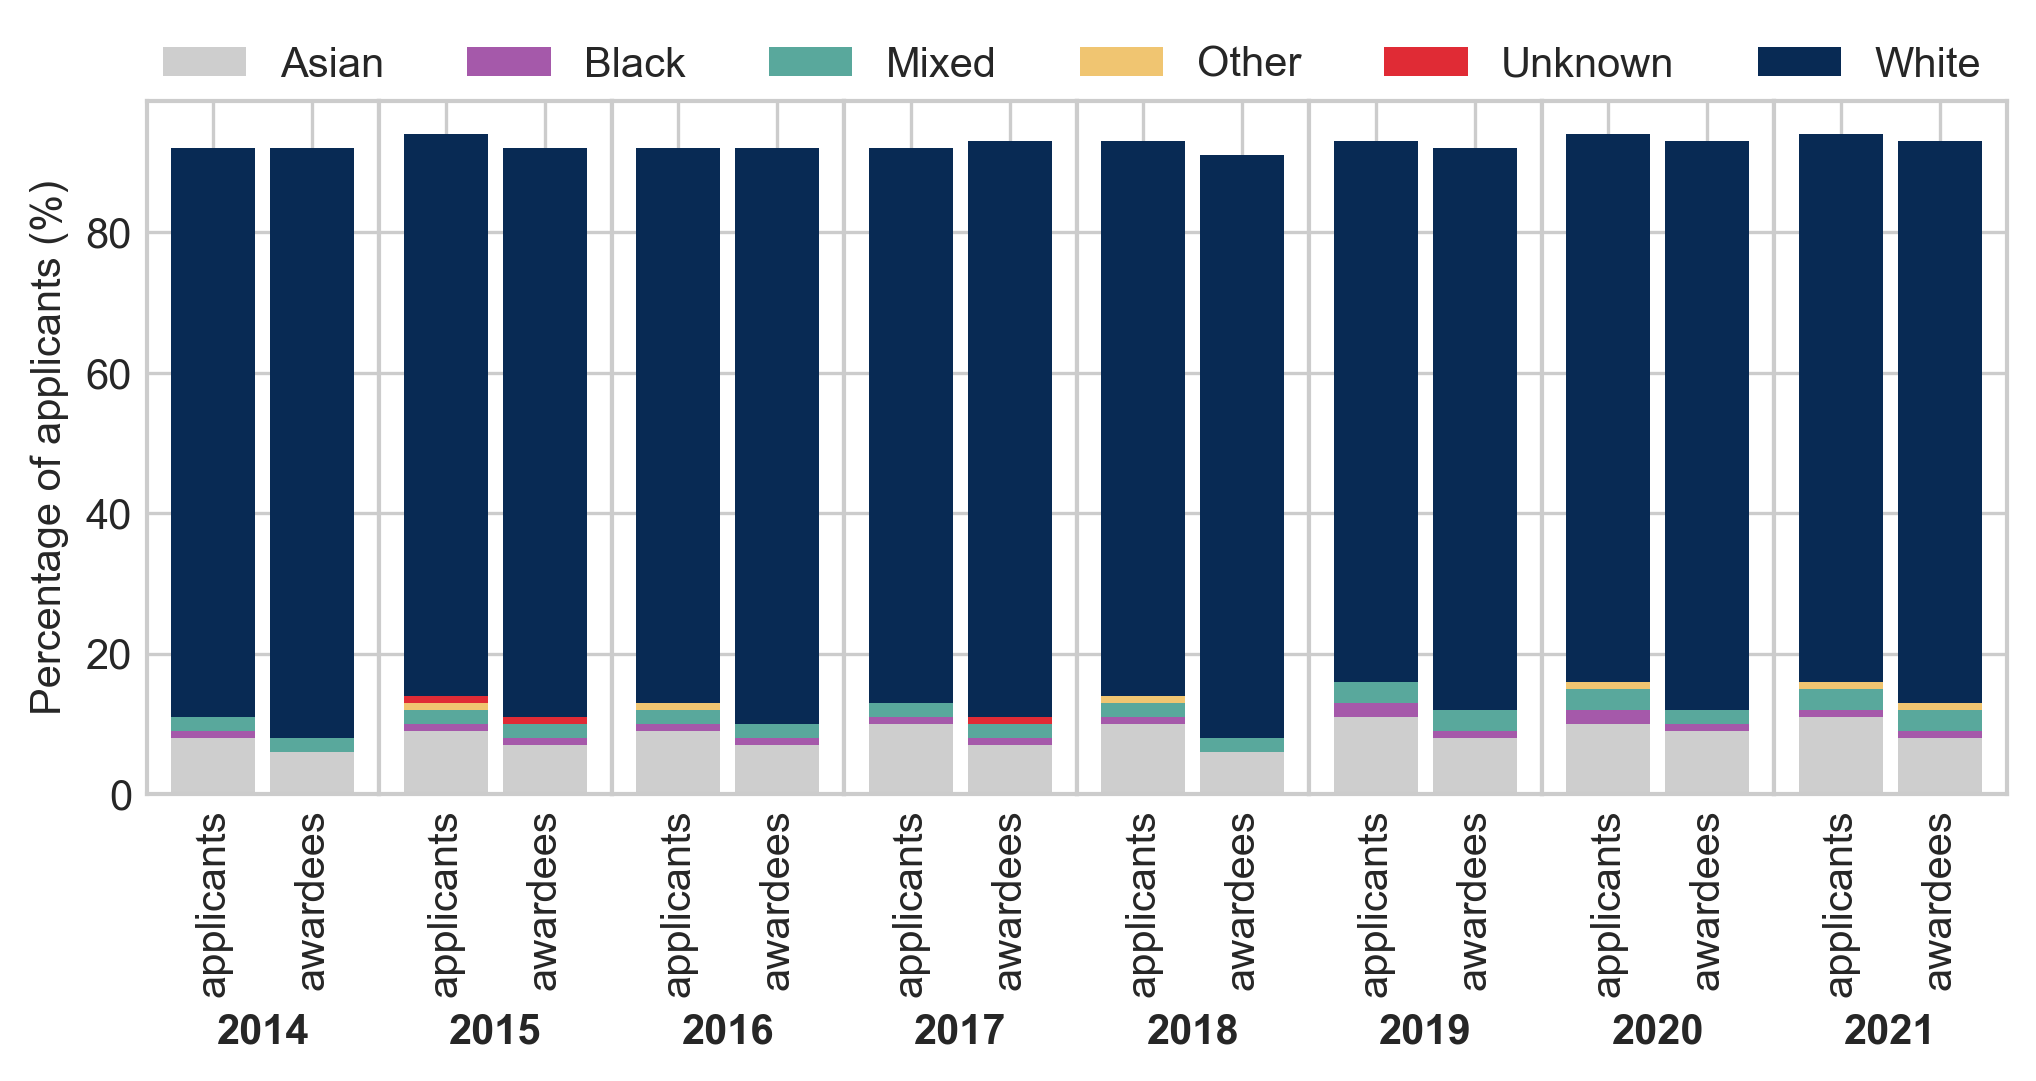

Average number of applicants per awardee = 1.00


In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\PI_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1] # get UKRI (all) data

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0).astype(float)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Type'])

#====================================
# Plotting numbers of applicants

df_plotting = ukri_applications[[ 'Asian','Black','Mixed','Other','Unknown','White']].copy()

n_subplots = len(df_plotting.index.levels[0])
fig, axes = plt.subplots(nrows=1, ncols=n_subplots, sharey=True, figsize=(8, 3),dpi=300)  # width, height

graph = dict(zip(df_plotting.index.levels[0], axes))
plots = list(map(lambda x: df_plotting.xs(x).plot(kind='bar', stacked='True', ax=graph[x], legend=False, width=0.85, color=colors).set_xlabel(x, weight='bold'), graph))


for ax in axes[1:]:
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('Percentage of applicants (%)')
plt.legend(ncols=6, frameon=False, loc=(-7,1))
fig.subplots_adjust(wspace=0)

#plt.ylim(50,100)

fname = 'UKRI_PI_breakdown_percentage.svg'
fname_tiff = 'UKRI_PI_breakdown_percentage.tiff'
filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"

plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')

plt.show()

print(f'Average number of applicants per awardee = {np.mean(ukri_applications.sum(axis=1)[0::2].to_numpy() /  ukri_applications.sum(axis=1)[1::2].to_numpy()) :.2f}')